# Predicting the 2026/27 Premier League through data science

Reproducible source for the revised article. The pipeline uses four player-value views, a five-season club layer, three technically distinct season engines, historical champion-points calibration and 10,000 full-season simulations per engine. The snapshot date is **22 August 2026**.

## Source acquisition and snapshot cache

The cell below downloads public source snapshots only when absent. Set `PL_FORECAST_CACHE` to reuse a frozen cache and `PL_FORECAST_OUTPUT` to redirect generated figures and tables. Transfermarkt values are collected from current club squad pages, not only its top-100 league leaderboard.

In [1]:
from pathlib import Path
import os
import re
from bs4 import BeautifulSoup
import requests

CACHE_ROOT = Path(os.environ.get("PL_FORECAST_CACHE", Path.cwd() / ".cache_pl_2026_27")).resolve()
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0 (compatible; reproducible football forecast)"})

def fetch(url, filename):
    target = CACHE_ROOT / filename
    if not target.exists():
        response = session.get(url, timeout=45)
        response.raise_for_status()
        target.write_bytes(response.content)
    return target

fetch("https://fantasy.premierleague.com/api/bootstrap-static/", "fpl_bootstrap.json")
for season in ("2021-22", "2022-23", "2023-24", "2024-25", "2025-26"):
    fetch(f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/players_raw.csv", f"fpl_players_{season}.csv")
for code in ("1617", "1718", "1819", "1920", "2021"):
    fetch(f"https://www.football-data.co.uk/mmz4281/{code}/E0.csv", f"matches_{code}_E0.csv")
for code in ("2122", "2223", "2324", "2425", "2526"):
    for division in ("E0", "E1"):
        fetch(f"https://www.football-data.co.uk/mmz4281/{code}/{division}.csv", f"matches_{code}_{division}.csv")
fetch("https://www.fotmob.com/leagues/47/stats/season/27110/players/rating", "fotmob_rating.html")
for page in range(1, 7):
    fetch(f"https://www.ea.com/en/games/ea-sports-fc/ratings/leagues-ratings/premier-league/13?page={page}", f"ea_page_{page}.html")

competition = fetch("https://www.transfermarkt.com/premier-league/startseite/wettbewerb/GB1", "transfermarkt_competition.html")
soup = BeautifulSoup(competition.read_text(encoding="utf-8"), "html.parser")
club_ids = sorted({match.group(1) for link in soup.select('a[href*="/startseite/verein/"]') if (match := re.search(r"/startseite/verein/(\d+)", link.get("href", "")))}, key=int)
for club_id in club_ids:
    fetch(f"https://www.transfermarkt.com/x/kader/verein/{club_id}/saison_id/2026", f"transfermarkt_squad_{club_id}.html")

print(f"Source cache ready: {CACHE_ROOT} ({len(club_ids)} Transfermarkt squads)")

Source cache ready: C:\Data\projects\django_site\django_site_AccidentalScientist\accidentalscientist2025\.private\article13_rebuild (20 Transfermarkt squads)


## Complete analysis pipeline

The code below performs conservative identity matching, hierarchical arithmetic-mean imputation, within-position percentile scoring, raw-top-100-plus-club-floor selection, team feature construction, chronological validation, historical calibration and all three simulations. Random seeds are fixed inside each calibration and production run.

In [2]:
from __future__ import annotations

from collections import defaultdict, deque
from dataclasses import dataclass
from datetime import date
from difflib import SequenceMatcher
import json
import math
import os
from pathlib import Path
import re
import unicodedata

from bs4 import BeautifulSoup
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss


ROOT = Path(os.environ.get("PL_FORECAST_CACHE", Path.cwd() / ".cache_pl_2026_27")).resolve()
OUT = Path(os.environ.get("PL_FORECAST_OUTPUT", ROOT / "outputs")).resolve()
OUT.mkdir(parents=True, exist_ok=True)

SNAPSHOT_DATE = "22 August 2026"
SEASONS = ["2021/22", "2022/23", "2023/24", "2024/25", "2025/26"]
MATCH_CODES = ["2122", "2223", "2324", "2425", "2526"]
MODEL_NAMES = ["Foundations Engine", "Disruption Engine", "Momentum Engine"]
MODEL_COLORS = {
    "Foundations Engine": "#315A7D",
    "Disruption Engine": "#A4672E",
    "Momentum Engine": "#6D568A",
}
MODEL_MARKERS = {"Foundations Engine": "o", "Disruption Engine": "s", "Momentum Engine": "D"}
MODEL_WEIGHTS = {"Foundations Engine": 0.35, "Disruption Engine": 0.40, "Momentum Engine": 0.25}
N_SIMS = 10_000

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


def normalise_text(value: object) -> str:
    text = unicodedata.normalize("NFKD", str(value or ""))
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = text.lower().replace("ø", "o").replace("đ", "d").replace("ł", "l")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return " ".join(text.split())


def display_name(element: dict) -> str:
    return " ".join(part for part in [element.get("first_name", ""), element.get("second_name", "")] if part).strip()


def read_next_data(path: Path) -> dict:
    soup = BeautifulSoup(path.read_bytes(), "html.parser")
    node = soup.select_one("script#__NEXT_DATA__")
    if node is None:
        raise ValueError(f"No __NEXT_DATA__ payload in {path.name}")
    return json.loads(node.string)


def parse_fpl_current() -> pd.DataFrame:
    payload = json.loads((ROOT / "fpl_bootstrap.json").read_text(encoding="utf-8"))
    teams = {item["id"]: item["name"] for item in payload["teams"]}
    position = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}
    rows = []
    for element in payload["elements"]:
        birth = pd.to_datetime(element.get("birth_date"), errors="coerce")
        age = (pd.Timestamp("2026-08-22") - birth).days / 365.25 if pd.notna(birth) else np.nan
        rows.append({
            "fpl_id": int(element["id"]),
            "code": int(element["code"]),
            "name": display_name(element),
            "web_name": element["web_name"],
            "current_team": teams[element["team"]],
            "position": position[element["element_type"]],
            "age": age,
        })
    return pd.DataFrame(rows)


def parse_ea() -> pd.DataFrame:
    rows = []
    for path in sorted(ROOT.glob("ea_page_*.html"), key=lambda item: int(re.search(r"(\d+)", item.stem).group(1))):
        payload = read_next_data(path)
        items = payload["props"]["pageProps"].get("ratingsEntries", {}).get("items", [])
        for item in items:
            first = item.get("firstName") or ""
            last = item.get("lastName") or ""
            rows.append({
                "source_id": item["id"],
                "source_name": item.get("commonName") or f"{first} {last}".strip(),
                "source_long_name": f"{first} {last}".strip(),
                "ea_overall": float(item["overallRating"]),
                "ea_club": (item.get("team") or {}).get("label", ""),
            })
    return pd.DataFrame(rows).drop_duplicates("source_id").reset_index(drop=True)


def parse_transfermarkt() -> pd.DataFrame:
    rows = []
    club_names = {
        "11": "Arsenal FC", "29": "Everton FC", "31": "Liverpool FC",
        "148": "Tottenham Hotspur", "281": "Manchester City",
        "289": "Sunderland AFC", "399": "Leeds United", "405": "Aston Villa",
        "631": "Chelsea FC", "677": "Ipswich Town", "703": "Nottingham Forest",
        "762": "Newcastle United", "873": "Crystal Palace", "931": "Fulham FC",
        "985": "Manchester United", "989": "AFC Bournemouth", "990": "Coventry City",
        "1148": "Brentford FC", "1237": "Brighton & Hove Albion", "3008": "Hull City",
    }
    squad_paths = sorted(
        ROOT.glob("transfermarkt_squad_*.html"),
        key=lambda item: int(re.search(r"(\d+)", item.stem).group(1)),
    )
    value_paths = squad_paths or sorted(
        ROOT.glob("transfermarkt_page_*.html"),
        key=lambda item: int(re.search(r"(\d+)", item.stem).group(1)),
    )
    for path in value_paths:
        soup = BeautifulSoup(path.read_text(encoding="utf-8"), "html.parser")
        table = soup.select_one("table.items")
        if table is None:
            continue
        club_id = re.search(r"squad_(\d+)", path.stem)
        path_club = club_names.get(club_id.group(1), "") if club_id else ""
        for row in table.select("tbody > tr.odd, tbody > tr.even, tbody > tr"):
            player_link = row.select_one('td.hauptlink a[href*="/profil/spieler/"]')
            value_cell = row.select_one("td.rechts.hauptlink")
            if player_link is None or value_cell is None:
                continue
            value_text = value_cell.get_text(" ", strip=True)
            match = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*([mk])", value_text.lower())
            if match is None:
                continue
            value = float(match.group(1)) * (1 if match.group(2) == "m" else 0.001)
            source_id = re.search(r"/spieler/(\d+)", player_link.get("href", ""))
            image_titles = [img.get("title") for img in row.select("img[title]") if img.get("title")]
            cells = row.select(":scope > td")
            position = ""
            if len(cells) > 1:
                nested = cells[1].select("table.inline-table tr")
                if len(nested) > 1:
                    position = nested[-1].get_text(" ", strip=True)
            rows.append({
                "source_id": int(source_id.group(1)) if source_id else player_link.get("href"),
                "source_name": player_link.get_text(" ", strip=True),
                "tm_position": position,
                "tm_club": path_club or (image_titles[-1] if image_titles else ""),
                "transfermarkt_m": value,
            })
    return pd.DataFrame(rows).drop_duplicates("source_id").reset_index(drop=True)


def parse_fotmob() -> pd.DataFrame:
    payload = read_next_data(ROOT / "fotmob_rating.html")
    items = payload["props"]["pageProps"]["data"]["statsData"]
    rows = []
    for item in items:
        value = item.get("statValue", {}).get("value")
        if value is None:
            continue
        rows.append({
            "source_id": item["id"],
            "source_name": item["name"],
            "fotmob_rating": float(value),
            "fotmob_rank": int(item["rank"]),
        })
    return pd.DataFrame(rows).drop_duplicates("source_id").reset_index(drop=True)


def name_variants(row: pd.Series, source: bool = False) -> list[str]:
    fields = ["source_name", "source_long_name"] if source else ["name", "web_name"]
    values = []
    for field in fields:
        if field in row and pd.notna(row[field]):
            value = normalise_text(row[field])
            if value:
                values.append(value)
                tokens = value.split()
                if len(tokens) > 2:
                    values.append(" ".join([tokens[0], tokens[-1]]))
    return list(dict.fromkeys(values))


def pair_score(left: pd.Series, right: pd.Series) -> float:
    left_values = name_variants(left, source=False)
    right_values = name_variants(right, source=True)
    if not left_values or not right_values:
        return 0.0
    score = max(SequenceMatcher(None, a, b).ratio() for a in left_values for b in right_values)
    left_last = {value.split()[-1] for value in left_values}
    right_last = {value.split()[-1] for value in right_values}
    if left_last & right_last:
        score += 0.08
    if any(a == b for a in left_values for b in right_values):
        score += 0.25
    return score


def greedy_name_match(players: pd.DataFrame, source: pd.DataFrame, threshold: float) -> pd.DataFrame:
    exact = defaultdict(list)
    for source_index, row in source.iterrows():
        for variant in name_variants(row, source=True):
            exact[variant].append(source_index)

    pairs = []
    locked_players = set()
    locked_source = set()
    for player_index, row in players.iterrows():
        candidates = set()
        for variant in name_variants(row, source=False):
            candidates.update(exact.get(variant, []))
        if len(candidates) == 1:
            source_index = next(iter(candidates))
            if source_index not in locked_source:
                pairs.append((player_index, source_index, 1.25))
                locked_players.add(player_index)
                locked_source.add(source_index)

    candidate_pairs = []
    remaining_source = [index for index in source.index if index not in locked_source]
    for player_index, player in players.loc[~players.index.isin(locked_players)].iterrows():
        for source_index in remaining_source:
            score = pair_score(player, source.loc[source_index])
            if score >= threshold:
                candidate_pairs.append((score, player_index, source_index))
    candidate_pairs.sort(reverse=True)
    for score, player_index, source_index in candidate_pairs:
        if player_index in locked_players or source_index in locked_source:
            continue
        pairs.append((player_index, source_index, score))
        locked_players.add(player_index)
        locked_source.add(source_index)

    return pd.DataFrame(pairs, columns=["player_index", "source_index", "match_score"])


def merge_source(players: pd.DataFrame, source: pd.DataFrame, columns: list[str], threshold: float, prefix: str) -> pd.DataFrame:
    matches = greedy_name_match(players, source, threshold)
    selected = matches.merge(source[columns], left_on="source_index", right_index=True, how="left")
    selected = selected.set_index("player_index")
    result = players.copy()
    for column in columns:
        result[column] = selected[column]
    result[f"{prefix}_match_score"] = selected["match_score"]
    return result


def build_fpl_history(players: pd.DataFrame) -> pd.DataFrame:
    season_weights = dict(zip(SEASONS, [0.10, 0.15, 0.20, 0.25, 0.30]))
    frames = []
    for season, label in zip(["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"], SEASONS):
        frame = pd.read_csv(ROOT / f"fpl_players_{season}.csv", low_memory=False)
        frame["season"] = label
        frame["weight"] = season_weights[label]
        frame["weighted_points"] = pd.to_numeric(frame["total_points"], errors="coerce").fillna(0) * frame["weight"]
        frame["weighted_minutes"] = pd.to_numeric(frame["minutes"], errors="coerce").fillna(0) * frame["weight"]
        frames.append(frame[["code", "weighted_points", "weighted_minutes", "minutes"]])
    hist = pd.concat(frames, ignore_index=True)
    hist5 = hist.groupby("code", as_index=False).agg(
        weighted_points=("weighted_points", "sum"),
        weighted_minutes=("weighted_minutes", "sum"),
        raw_five_year_minutes=("minutes", "sum"),
    )
    hist5["points_per_90"] = np.where(
        hist5["weighted_minutes"] > 0,
        90 * hist5["weighted_points"] / hist5["weighted_minutes"],
        np.nan,
    )
    hist5["history_reliability"] = (hist5["weighted_minutes"] / 2_000).clip(0, 1)
    return players.merge(hist5, on="code", how="left")


def hierarchical_mean_impute(frame: pd.DataFrame, column: str, primary: list[str]) -> pd.DataFrame:
    frame = frame.copy()
    flag = f"{column}_imputed"
    frame[flag] = frame[column].isna()
    for group_columns in [primary, ["position"], []]:
        missing = frame[column].isna()
        if not missing.any():
            break
        if group_columns:
            means = frame.groupby(group_columns, observed=True)[column].transform("mean")
            frame.loc[missing, column] = means[missing]
        else:
            frame.loc[missing, column] = frame[column].mean()
    if frame[column].isna().any():
        raise AssertionError(f"Imputation failed for {column}")
    return frame


def build_player_layer() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    players = parse_fpl_current()
    players = merge_source(players, parse_ea(), ["source_name", "ea_overall", "ea_club"], 0.82, "ea")
    players = players.rename(columns={"source_name": "ea_source_name"})
    players = merge_source(players, parse_transfermarkt(), ["source_name", "transfermarkt_m", "tm_club"], 0.82, "tm")
    players = players.rename(columns={"source_name": "tm_source_name"})
    players = merge_source(players, parse_fotmob(), ["source_name", "fotmob_rating"], 0.82, "fotmob")
    players = players.rename(columns={"source_name": "fotmob_source_name"})
    players = build_fpl_history(players)

    players["age_band"] = pd.cut(players["age"], bins=[0, 21, 24, 27, 30, 100], labels=["U21", "22-24", "25-27", "28-30", "31+"])
    players = hierarchical_mean_impute(players, "ea_overall", ["position"])
    players = hierarchical_mean_impute(players, "transfermarkt_m", ["position", "age_band"])
    players = hierarchical_mean_impute(players, "points_per_90", ["position"])
    players = hierarchical_mean_impute(players, "fotmob_rating", ["position"])
    players["history_reliability"] = players["history_reliability"].fillna(0)

    players["ea_percentile"] = players.groupby("position")["ea_overall"].rank(pct=True)
    players["tm_percentile"] = players.groupby("position")["transfermarkt_m"].rank(pct=True)
    players["history_percentile"] = players.groupby("position")["points_per_90"].rank(pct=True)
    players["fotmob_percentile"] = players.groupby("position")["fotmob_rating"].rank(pct=True)
    players["player_score"] = 100 * (
        0.25 * players["ea_percentile"]
        + 0.25 * players["tm_percentile"]
        + 0.25 * players["history_percentile"]
        + 0.25 * players["fotmob_percentile"]
    )
    players["raw_rank"] = players["player_score"].rank(method="first", ascending=False).astype(int)
    players = players.sort_values("raw_rank").reset_index(drop=True)

    raw_top100 = players.head(100).copy()
    selected_ids = set(raw_top100["fpl_id"])
    additions = []
    for club, club_frame in players.groupby("current_team"):
        existing = int(club_frame["fpl_id"].isin(selected_ids).sum())
        if existing < 3:
            available = club_frame[~club_frame["fpl_id"].isin(selected_ids)].head(3 - existing)
            additions.append(available)
            selected_ids.update(available["fpl_id"])
    floor_additions = pd.concat(additions, ignore_index=True) if additions else players.iloc[0:0].copy()
    raw_top100["selection_reason"] = "Raw top 100"
    floor_additions["selection_reason"] = "Three-player club floor"
    published = pd.concat([raw_top100, floor_additions.sort_values("raw_rank")], ignore_index=True)
    published["published_order"] = np.arange(1, len(published) + 1)

    counts = published.groupby("current_team").size().rename("selected_players").sort_values(ascending=False)
    assert len(raw_top100) == 100
    assert counts.min() >= 3
    assert not published[["ea_overall", "transfermarkt_m", "points_per_90", "fotmob_rating"]].isna().any().any()

    players.to_csv(OUT / "current_player_pool_enriched.csv", index=False)
    published.to_csv(OUT / "premier_league_top100_plus_floor.csv", index=False)
    imputation = pd.DataFrame({
        "metric": ["EA overall", "Transfermarkt value", "Five-year points per 90", "FotMob rating"],
        "matched_or_observed": [
            int((~players["ea_overall_imputed"]).sum()),
            int((~players["transfermarkt_m_imputed"]).sum()),
            int((~players["points_per_90_imputed"]).sum()),
            int((~players["fotmob_rating_imputed"]).sum()),
        ],
        "imputed": [
            int(players["ea_overall_imputed"].sum()),
            int(players["transfermarkt_m_imputed"].sum()),
            int(players["points_per_90_imputed"].sum()),
            int(players["fotmob_rating_imputed"].sum()),
        ],
    })
    imputation.to_csv(OUT / "player_metric_imputation.csv", index=False)
    return players, published, imputation


def load_matches() -> pd.DataFrame:
    frames = []
    for season, code in zip(SEASONS, MATCH_CODES):
        for division in ("E0", "E1"):
            frame = pd.read_csv(ROOT / f"matches_{code}_{division}.csv")
            frame["season"] = season
            frame["division"] = division
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def build_team_seasons(matches: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (season, division), frame in matches.groupby(["season", "division"]):
        clubs = sorted(set(frame["HomeTeam"]) | set(frame["AwayTeam"]))
        for club in clubs:
            home = frame[frame["HomeTeam"] == club]
            away = frame[frame["AwayTeam"] == club]
            gf = home["FTHG"].sum() + away["FTAG"].sum()
            ga = home["FTAG"].sum() + away["FTHG"].sum()
            points = (
                3 * (home["FTR"] == "H").sum() + (home["FTR"] == "D").sum()
                + 3 * (away["FTR"] == "A").sum() + (away["FTR"] == "D").sum()
            )
            played = len(home) + len(away)
            rows.append({
                "season": season,
                "division": division,
                "team_history": club,
                "played": played,
                "points": points,
                "ppg": points / played,
                "gd_per_game": (gf - ga) / played,
            })
    result = pd.DataFrame(rows)
    for column in ["ppg", "gd_per_game"]:
        result[f"z_{column}"] = result.groupby(["season", "division"])[column].transform(
            lambda values: (values - values.mean()) / values.std(ddof=0)
        )
    result["within_division_strength"] = 0.65 * result["z_ppg"] + 0.35 * result["z_gd_per_game"]
    result["tier_adjusted_strength"] = np.where(
        result["division"].eq("E0"),
        result["within_division_strength"],
        0.55 * result["within_division_strength"] - 1.15,
    )
    return result


def standardise(values: pd.Series | np.ndarray) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    return (array - array.mean()) / array.std(ddof=0)


HISTORY_NAME = {
    "Arsenal": "Arsenal", "Aston Villa": "Aston Villa", "Bournemouth": "Bournemouth",
    "Brentford": "Brentford", "Brighton": "Brighton", "Chelsea": "Chelsea",
    "Coventry City": "Coventry", "Crystal Palace": "Crystal Palace", "Everton": "Everton",
    "Fulham": "Fulham", "Hull City": "Hull", "Ipswich Town": "Ipswich", "Leeds": "Leeds",
    "Liverpool": "Liverpool", "Man City": "Man City", "Man Utd": "Man United",
    "Newcastle": "Newcastle", "Nott'm Forest": "Nott'm Forest", "Spurs": "Tottenham",
    "Sunderland": "Sunderland",
}


def build_team_inputs(players: pd.DataFrame, matches: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    teams = sorted(players["current_team"].unique())
    team_seasons = build_team_seasons(matches)
    recency = dict(zip(SEASONS, [0.10, 0.15, 0.20, 0.25, 0.30]))

    def horizon_table(n_seasons: int) -> pd.DataFrame:
        chosen = SEASONS[-n_seasons:]
        weights = {season: recency[season] for season in chosen}
        total_weight = sum(weights.values())
        records = []
        for club in teams:
            subset = team_seasons[
                (team_seasons["team_history"] == HISTORY_NAME[club])
                & (team_seasons["season"].isin(chosen))
            ].copy()
            subset["weight"] = subset["season"].map(weights)
            strength = (subset["tier_adjusted_strength"] * subset["weight"]).sum() / total_weight
            records.append({"current_team": club, f"history_{n_seasons}y": strength})
        result = pd.DataFrame(records)
        result[f"rank_{n_seasons}y"] = result[f"history_{n_seasons}y"].rank(ascending=False).astype(int)
        return result

    history_compare = horizon_table(1).merge(horizon_table(3), on="current_team").merge(horizon_table(5), on="current_team")
    history_compare = history_compare.sort_values("rank_5y")

    aliases = {
        "Manchester City": "Man City", "Manchester United": "Man Utd", "Tottenham Hotspur": "Spurs",
        "Newcastle United": "Newcastle", "Newcastle Utd": "Newcastle", "Leeds United": "Leeds",
        "Nottingham Forest": "Nott'm Forest", "AFC Bournemouth": "Bournemouth",
        "Coventry": "Coventry City", "Hull": "Hull City", "Ipswich": "Ipswich Town",
    }
    players = players.copy()
    players["ea_club_normalised"] = players["ea_club"].map(lambda value: aliases.get(value, value))
    squad_rows = []
    for club, subset in players.groupby("current_team"):
        subset = subset.sort_values("player_score", ascending=False).reset_index(drop=True)
        formation = {"GK": 1, "DEF": 4, "MID": 4, "FWD": 2}
        core = pd.concat([subset[subset["position"] == position].head(count) for position, count in formation.items()])
        core = core.drop_duplicates("fpl_id").sort_values("player_score", ascending=False)
        remaining = subset[~subset["fpl_id"].isin(core["fpl_id"])]
        depth = remaining.head(4)
        top3 = subset.head(3)
        top15 = pd.concat([core, depth]).drop_duplicates("fpl_id")
        imputation_share = top15[[
            "ea_overall_imputed", "transfermarkt_m_imputed", "points_per_90_imputed", "fotmob_rating_imputed"
        ]].mean().mean()
        squad_rows.append({
            "current_team": club,
            "core_score": core["player_score"].mean(),
            "depth_score": depth["player_score"].mean(),
            "elite_score": top3["player_score"].mean(),
            "squad_raw": 0.70 * core["player_score"].mean() + 0.20 * depth["player_score"].mean() + 0.10 * top3["player_score"].mean(),
            "transfer_share": (top15["ea_club_normalised"] != club).fillna(True).mean(),
            "imputation_share": imputation_share,
            "history_reliability": top15["history_reliability"].mean(),
            "selected_player_anchors": int((top15["raw_rank"] <= 100).sum()),
        })
    squads = pd.DataFrame(squad_rows)
    squads["squad_strength"] = standardise(squads["squad_raw"])

    managers = {
        "Arsenal": ("Mikel Arteta", False), "Aston Villa": ("Unai Emery", False),
        "Bournemouth": ("Marco Rose", True), "Brentford": ("Keith Andrews", False),
        "Brighton": ("Fabian Hurzeler", False), "Chelsea": ("Xabi Alonso", True),
        "Coventry City": ("Frank Lampard", False), "Crystal Palace": ("Pierre Sage", True),
        "Everton": ("David Moyes", False), "Fulham": ("Alvaro Arbeloa", True),
        "Hull City": ("Sergej Jakirovic", False), "Ipswich Town": ("Gary O'Neil", True),
        "Leeds": ("Daniel Farke", False), "Liverpool": ("Andoni Iraola", True),
        "Man City": ("Enzo Maresca", True), "Man Utd": ("Michael Carrick", True),
        "Newcastle": ("Vacant at snapshot", True), "Nott'm Forest": ("Oliver Glasner", True),
        "Sunderland": ("Regis Le Bris", False), "Spurs": ("Roberto De Zerbi", True),
    }
    europe = {
        "Arsenal": "UCL", "Aston Villa": "UCL", "Liverpool": "UCL", "Man City": "UCL", "Man Utd": "UCL",
        "Bournemouth": "UEL", "Sunderland": "UEL", "Crystal Palace": "UEL", "Brighton": "UECL qualifier",
    }
    promoted = {"Coventry City", "Hull City", "Ipswich Town"}
    second_year = {"Leeds", "Sunderland"}

    context = pd.DataFrame({"current_team": teams})
    context["manager"] = context["current_team"].map(lambda club: managers[club][0])
    context["manager_change"] = context["current_team"].map(lambda club: managers[club][1])
    context["europe"] = context["current_team"].map(europe).fillna("None")
    context["competitions"] = np.where(context["europe"].eq("None"), 3, 4)
    context["promoted"] = context["current_team"].isin(promoted)
    context["second_year_PL"] = context["current_team"].isin(second_year)

    team_model = history_compare[["current_team", "history_5y"]].merge(squads, on="current_team").merge(context, on="current_team")
    team_model["history_strength"] = standardise(team_model["history_5y"])
    team_model["base_strength"] = standardise(0.50 * team_model["history_strength"] + 0.50 * team_model["squad_strength"])
    team_model["schedule_penalty"] = team_model["europe"].map({"UCL": -0.04, "UEL": -0.03, "UECL qualifier": -0.02, "None": 0.0})

    season_vol = team_seasons[team_seasons["team_history"].isin(HISTORY_NAME.values())].groupby("team_history")["tier_adjusted_strength"].std()
    team_model["historical_volatility"] = team_model["current_team"].map(lambda club: season_vol.get(HISTORY_NAME[club], 0.7)).fillna(0.7)
    team_model["data_sigma"] = 0.08 * team_model["imputation_share"] + 0.08 * (1 - team_model["history_reliability"])

    team_model.to_csv(OUT / "team_model_inputs.csv", index=False)
    history_compare.to_csv(OUT / "history_horizon_comparison.csv", index=False)
    return team_model, history_compare, team_seasons


def champion_history() -> pd.DataFrame:
    seasons = ["2016/17", "2017/18", "2018/19", "2019/20", "2020/21", *SEASONS]
    codes = ["1617", "1718", "1819", "1920", "2021", *MATCH_CODES]
    rows = []
    for season, code in zip(seasons, codes):
        frame = pd.read_csv(ROOT / f"matches_{code}_E0.csv")
        clubs = sorted(set(frame["HomeTeam"]) | set(frame["AwayTeam"]))
        table = []
        for club in clubs:
            home = frame[frame["HomeTeam"] == club]
            away = frame[frame["AwayTeam"] == club]
            points = (
                3 * (home["FTR"] == "H").sum() + (home["FTR"] == "D").sum()
                + 3 * (away["FTR"] == "A").sum() + (away["FTR"] == "D").sum()
            )
            gd = home["FTHG"].sum() + away["FTAG"].sum() - home["FTAG"].sum() - away["FTHG"].sum()
            table.append((club, int(points), int(gd)))
        winner = sorted(table, key=lambda item: (item[1], item[2]), reverse=True)[0]
        rows.append({"season": season, "champion": winner[0], "points": winner[1]})
    result = pd.DataFrame(rows)
    result.to_csv(OUT / "last_ten_champions.csv", index=False)
    return result


def positions_from_points(points: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    jitter = rng.normal(0, 1e-3, size=points.shape)
    order = np.argsort(-(points + jitter), axis=1)
    positions = np.empty_like(order)
    positions[np.arange(len(points))[:, None], order] = np.arange(1, points.shape[1] + 1)
    return positions


def finish_summary(points: np.ndarray, positions: np.ndarray, teams: list[str], model_name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "current_team": teams,
        "model": model_name,
        "mean_points": points.mean(axis=0),
        "sd_points": points.std(axis=0),
        "p10_points": np.percentile(points, 10, axis=0),
        "p90_points": np.percentile(points, 90, axis=0),
        "title_probability": (positions == 1).mean(axis=0),
        "median_position": np.median(positions, axis=0),
    })


def apply_softmax_fixture(
    points: np.ndarray,
    latent: np.ndarray,
    home: int,
    away: int,
    rng: np.random.Generator,
    coefficient: float,
    home_bonus: float = 0.22,
    home_match_noise: np.ndarray | None = None,
    away_match_noise: np.ndarray | None = None,
) -> None:
    diff = latent[:, home] - latent[:, away]
    if home_match_noise is not None:
        diff = diff + home_match_noise
    if away_match_noise is not None:
        diff = diff - away_match_noise
    home_logit = home_bonus + coefficient * diff
    away_logit = -home_bonus - coefficient * diff
    draw_logit = -0.08 - 0.08 * np.abs(diff)
    ceiling = np.maximum.reduce([home_logit, away_logit, draw_logit])
    exp_home = np.exp(home_logit - ceiling)
    exp_away = np.exp(away_logit - ceiling)
    exp_draw = np.exp(draw_logit - ceiling)
    total = exp_home + exp_away + exp_draw
    p_home = exp_home / total
    p_draw = exp_draw / total
    draw = rng.random(len(points))
    home_win = draw < p_home
    tied = (draw >= p_home) & (draw < p_home + p_draw)
    away_win = ~(home_win | tied)
    points[:, home] += 3 * home_win + tied
    points[:, away] += 3 * away_win + tied


def simulate_foundations(
    base_strength: np.ndarray,
    teams: list[str],
    coefficient: float,
    k: float = 0.42,
    n_sims: int = N_SIMS,
    seed: int = 1101,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    latent = base_strength[None, :] + rng.normal(0, k, size=(n_sims, len(teams)))
    points = np.zeros((n_sims, len(teams)), dtype=np.int16)
    for home in range(len(teams)):
        for away in range(len(teams)):
            if home != away:
                apply_softmax_fixture(points, latent, home, away, rng, coefficient=coefficient)
    positions = positions_from_points(points, rng)
    return finish_summary(points, positions, teams, MODEL_NAMES[0]), points, positions


def build_venues(teams: list[str], matches: pd.DataFrame) -> pd.DataFrame:
    weights = dict(zip(SEASONS, [0.10, 0.15, 0.20, 0.25, 0.30]))
    rows = []
    for club in teams:
        pieces = []
        history_club = HISTORY_NAME[club]
        for season, frame in matches.groupby("season"):
            home = frame[frame["HomeTeam"] == history_club]
            away = frame[frame["AwayTeam"] == history_club]
            if len(home) and len(away):
                home_points = 3 * (home["FTR"] == "H").sum() + (home["FTR"] == "D").sum()
                away_points = 3 * (away["FTR"] == "A").sum() + (away["FTR"] == "D").sum()
                pieces.append((weights[season], home_points / len(home), away_points / len(away)))
        total_weight = sum(item[0] for item in pieces)
        rows.append({
            "current_team": club,
            "home_ppg": sum(item[0] * item[1] for item in pieces) / total_weight,
            "away_ppg": sum(item[0] * item[2] for item in pieces) / total_weight,
        })
    venues = pd.DataFrame(rows)
    venues["raw_home_lift"] = venues["home_ppg"] - venues["away_ppg"]
    venues["stadium_bonus"] = (0.07 * standardise(venues["raw_home_lift"])).clip(-0.11, 0.11)
    return venues


def simulate_disruption(
    ordered: pd.DataFrame,
    teams: list[str],
    venues: pd.DataFrame,
    coefficient: float,
    n_sims: int = N_SIMS,
    seed: int = 2202,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    n = len(teams)
    context = ordered.reset_index().merge(venues, on="current_team").set_index("current_team").loc[teams]
    base_shock = rng.normal(0, 0.28, size=(n_sims, n))
    coach_sd = np.where(context["manager_change"], 0.20, 0.06)
    transfer_sd = 0.27 * context["transfer_share"].to_numpy()
    transition_sd = 0.16 * context["promoted"].to_numpy() + 0.09 * context["second_year_PL"].to_numpy()
    data_sd = context["data_sigma"].to_numpy()
    coach_shock = rng.normal(0, coach_sd[None, :], size=(n_sims, n))
    transfer_shock = rng.normal(0, transfer_sd[None, :], size=(n_sims, n))
    transition_shock = rng.standard_t(5, size=(n_sims, n)) * transition_sd[None, :]
    data_shock = rng.normal(0, data_sd[None, :], size=(n_sims, n))
    euro_flag = context["competitions"].to_numpy() == 4
    euro_season = rng.normal(-0.03 * euro_flag, 0.07 * euro_flag, size=(n_sims, n))
    latent = (
        context["base_strength"].to_numpy()[None, :]
        + base_shock + coach_shock + transfer_shock + transition_shock + data_shock + euro_season
    )
    points = np.zeros((n_sims, n), dtype=np.int16)
    for home in range(n):
        for away in range(n):
            if home == away:
                continue
            home_noise = rng.normal(0, 0.08, n_sims)
            away_noise = rng.normal(0, 0.08, n_sims)
            if euro_flag[home]:
                home_noise -= rng.binomial(1, 0.28, n_sims) * np.abs(rng.normal(0.10, 0.04, n_sims))
            if euro_flag[away]:
                away_noise -= rng.binomial(1, 0.28, n_sims) * np.abs(rng.normal(0.10, 0.04, n_sims))
            apply_softmax_fixture(
                points, latent, home, away, rng,
                coefficient=coefficient,
                home_bonus=0.22 + context["stadium_bonus"].iloc[home],
                home_match_noise=home_noise,
                away_match_noise=away_noise,
            )
    positions = positions_from_points(points, rng)
    components = pd.DataFrame({
        "current_team": teams,
        "coach_sd": coach_sd,
        "transfer_sd": transfer_sd,
        "transition_sd": transition_sd,
        "data_sd": data_sd,
        "europe_sd": euro_flag * 0.07,
    })
    return finish_summary(points, positions, teams, MODEL_NAMES[1]), points, positions, components


def initial_state(base_elo: float) -> dict:
    return {
        "elo": base_elo,
        "ppg": deque(maxlen=10),
        "gd": deque(maxlen=10),
        "home_ppg": deque(maxlen=8),
        "away_ppg": deque(maxlen=8),
        "last_date": None,
    }


def mean_or(values: deque, default: float) -> float:
    return float(np.mean(values)) if len(values) else default


FEATURES = [
    "elo_diff", "recent_ppg_diff", "recent_gd_diff", "home_venue_ppg",
    "away_venue_ppg", "rest_diff", "division_top", "season_progress",
]


def make_ml_training(matches: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    data = matches.copy()
    data["parsed_date"] = pd.to_datetime(data["Date"], dayfirst=True, errors="coerce")
    data = data.sort_values(["parsed_date", "division", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
    states: dict[str, dict] = {}
    rows = []
    season_game = defaultdict(int)
    season_total = data.groupby(["season", "division"]).size().to_dict()
    for row in data.itertuples():
        default_elo = 1500 if row.division == "E0" else 1380
        home_state = states.setdefault(row.HomeTeam, initial_state(default_elo))
        away_state = states.setdefault(row.AwayTeam, initial_state(default_elo))
        if home_state["last_date"] is None or away_state["last_date"] is None:
            rest_diff = 0
        else:
            rest_diff = np.clip(
                (row.parsed_date - home_state["last_date"]).days
                - (row.parsed_date - away_state["last_date"]).days,
                -10,
                10,
            )
        key = (row.season, row.division)
        rows.append({
            "season": row.season,
            "division": row.division,
            "home_team": row.HomeTeam,
            "away_team": row.AwayTeam,
            "elo_diff": home_state["elo"] - away_state["elo"],
            "recent_ppg_diff": mean_or(home_state["ppg"], 1.35) - mean_or(away_state["ppg"], 1.35),
            "recent_gd_diff": mean_or(home_state["gd"], 0) - mean_or(away_state["gd"], 0),
            "home_venue_ppg": mean_or(home_state["home_ppg"], 1.55),
            "away_venue_ppg": mean_or(away_state["away_ppg"], 1.15),
            "rest_diff": rest_diff,
            "division_top": int(row.division == "E0"),
            "season_progress": season_game[key] / season_total[key],
            "target": row.FTR,
        })
        season_game[key] += 1
        home_points = 3 if row.FTR == "H" else 1 if row.FTR == "D" else 0
        away_points = 3 if row.FTR == "A" else 1 if row.FTR == "D" else 0
        margin = row.FTHG - row.FTAG
        home_state["ppg"].append(home_points)
        away_state["ppg"].append(away_points)
        home_state["gd"].append(margin)
        away_state["gd"].append(-margin)
        home_state["home_ppg"].append(home_points)
        away_state["away_ppg"].append(away_points)
        expected = 1 / (1 + 10 ** (-((home_state["elo"] - away_state["elo"] + 65) / 400)))
        actual = 1 if row.FTR == "H" else 0.5 if row.FTR == "D" else 0
        change = 22 * np.log1p(abs(margin)) * (actual - expected)
        home_state["elo"] += change
        away_state["elo"] -= change
        home_state["last_date"] = row.parsed_date
        away_state["last_date"] = row.parsed_date
    return pd.DataFrame(rows), states


def circle_schedule(n: int) -> list[list[tuple[int, int]]]:
    fixed = list(range(n))
    first_half = []
    for round_no in range(n - 1):
        pairs = []
        for index in range(n // 2):
            home, away = fixed[index], fixed[n - 1 - index]
            if (round_no + index) % 2:
                home, away = away, home
            pairs.append((home, away))
        first_half.append(pairs)
        fixed = [fixed[0]] + [fixed[-1]] + fixed[1:-1]
    return first_half + [[(away, home) for home, away in round_pairs] for round_pairs in first_half]


@dataclass
class MLBundle:
    model: HistGradientBoostingClassifier
    validation: pd.DataFrame
    final_states: dict
    data: pd.DataFrame


def train_momentum(matches: pd.DataFrame) -> MLBundle:
    ml_data, final_states = make_ml_training(matches)
    train = ml_data[ml_data["season"] != "2025/26"]
    test = ml_data[ml_data["season"] == "2025/26"]
    validation_model = HistGradientBoostingClassifier(
        learning_rate=0.025,
        max_iter=250,
        max_leaf_nodes=5,
        min_samples_leaf=80,
        l2_regularization=5.0,
        random_state=3301,
    ).fit(train[FEATURES], train["target"])
    probability = validation_model.predict_proba(test[FEATURES])
    prediction = validation_model.predict(test[FEATURES])
    onehot = pd.get_dummies(pd.Categorical(test["target"], categories=validation_model.classes_)).to_numpy()
    class_prior = train["target"].value_counts(normalize=True).reindex(validation_model.classes_).to_numpy()
    baseline = np.tile(class_prior, (len(test), 1))
    validation = pd.DataFrame({
        "metric": ["Accuracy", "Multiclass log loss", "Multiclass Brier score"],
        "Momentum Engine": [
            accuracy_score(test["target"], prediction),
            log_loss(test["target"], probability, labels=validation_model.classes_),
            np.mean(np.sum((probability - onehot) ** 2, axis=1)),
        ],
        "Unconditional baseline": [
            class_prior.max(),
            log_loss(test["target"], baseline, labels=validation_model.classes_),
            np.mean(np.sum((baseline - onehot) ** 2, axis=1)),
        ],
    })
    model = HistGradientBoostingClassifier(
        learning_rate=0.025,
        max_iter=250,
        max_leaf_nodes=5,
        min_samples_leaf=80,
        l2_regularization=5.0,
        random_state=3302,
    ).fit(ml_data[FEATURES], ml_data["target"])
    validation.to_csv(OUT / "momentum_holdout_metrics.csv", index=False)
    ml_data.to_csv(OUT / "momentum_training_table.csv", index=False)
    return MLBundle(model=model, validation=validation, final_states=final_states, data=ml_data)


def simulate_momentum(
    bundle: MLBundle,
    ordered: pd.DataFrame,
    teams: list[str],
    temperature: float,
    n_sims: int = N_SIMS,
    seed: int = 3303,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    n = len(teams)
    historical_elo = np.array([bundle.final_states[HISTORY_NAME[team]]["elo"] for team in teams])
    elo = historical_elo[None, :] + 55 * ordered["squad_strength"].to_numpy()[None, :]
    elo = np.repeat(elo, n_sims, axis=0)
    ppg = np.array([mean_or(bundle.final_states[HISTORY_NAME[team]]["ppg"], 1.35) for team in teams])[None, :]
    gd = np.array([mean_or(bundle.final_states[HISTORY_NAME[team]]["gd"], 0) for team in teams])[None, :]
    home_ppg = np.array([mean_or(bundle.final_states[HISTORY_NAME[team]]["home_ppg"], 1.55) for team in teams])[None, :]
    away_ppg = np.array([mean_or(bundle.final_states[HISTORY_NAME[team]]["away_ppg"], 1.15) for team in teams])[None, :]
    ppg = np.repeat(ppg, n_sims, axis=0)
    gd = np.repeat(gd, n_sims, axis=0)
    home_ppg = np.repeat(home_ppg, n_sims, axis=0)
    away_ppg = np.repeat(away_ppg, n_sims, axis=0)
    regime_sd = 0.22 + 0.12 * ordered["transfer_share"].to_numpy() + 0.08 * ordered["promoted"].to_numpy() + ordered["data_sigma"].to_numpy()
    regime = rng.standard_t(4, size=(n_sims, n)) * regime_sd[None, :]
    points = np.zeros((n_sims, n), dtype=np.int16)
    class_index = {label: index for index, label in enumerate(bundle.model.classes_)}
    for round_no, fixtures in enumerate(circle_schedule(n)):
        for home, away in fixtures:
            features = pd.DataFrame({
                "elo_diff": elo[:, home] - elo[:, away] + 75 * (regime[:, home] - regime[:, away]),
                "recent_ppg_diff": ppg[:, home] - ppg[:, away],
                "recent_gd_diff": gd[:, home] - gd[:, away],
                "home_venue_ppg": home_ppg[:, home],
                "away_venue_ppg": away_ppg[:, away],
                "rest_diff": np.zeros(n_sims),
                "division_top": np.ones(n_sims),
                "season_progress": np.full(n_sims, round_no / 38),
            })[FEATURES]
            probability = bundle.model.predict_proba(features)
            probability = np.power(np.clip(probability, 1e-8, 1), 1 / temperature)
            probability /= probability.sum(axis=1, keepdims=True)
            draw = rng.random(n_sims)
            p_away = probability[:, class_index["A"]]
            p_tie = probability[:, class_index["D"]]
            away_win = draw < p_away
            tied = (draw >= p_away) & (draw < p_away + p_tie)
            home_win = ~(away_win | tied)
            home_points = 3 * home_win + tied
            away_points = 3 * away_win + tied
            points[:, home] += home_points
            points[:, away] += away_points
            margin = home_win.astype(float) - away_win.astype(float)
            ppg[:, home] = 0.85 * ppg[:, home] + 0.15 * home_points
            ppg[:, away] = 0.85 * ppg[:, away] + 0.15 * away_points
            gd[:, home] = 0.85 * gd[:, home] + 0.15 * margin
            gd[:, away] = 0.85 * gd[:, away] - 0.15 * margin
            home_ppg[:, home] = 0.88 * home_ppg[:, home] + 0.12 * home_points
            away_ppg[:, away] = 0.88 * away_ppg[:, away] + 0.12 * away_points
            expected = 1 / (1 + 10 ** (-((elo[:, home] - elo[:, away] + 65) / 400)))
            actual = home_win + 0.5 * tied
            change = 18 * (actual - expected)
            elo[:, home] += change
            elo[:, away] -= change
    positions = positions_from_points(points, rng)
    return finish_summary(points, positions, teams, MODEL_NAMES[2]), points, positions


def calibrate_foundations(base_strength: np.ndarray, teams: list[str], target: float) -> tuple[float, pd.DataFrame]:
    rows = []
    for index, coefficient in enumerate(np.linspace(0.35, 1.10, 16)):
        _, points, _ = simulate_foundations(base_strength, teams, coefficient, n_sims=1_500, seed=7100 + index)
        rows.append({"coefficient": coefficient, "simulated_champion_mean": points.max(axis=1).mean()})
    table = pd.DataFrame(rows)
    selected = float(table.iloc[(table["simulated_champion_mean"] - target).abs().argmin()]["coefficient"])
    table["historical_target"] = target
    table.to_csv(OUT / "foundations_calibration_grid.csv", index=False)
    return selected, table


def calibrate_momentum(bundle: MLBundle, ordered: pd.DataFrame, teams: list[str], target: float) -> tuple[float, pd.DataFrame]:
    rows = []
    for index, temperature in enumerate([0.65, 0.75, 0.85, 0.95, 1.05, 1.15]):
        _, points, _ = simulate_momentum(bundle, ordered, teams, temperature, n_sims=1_000, seed=8100 + index)
        rows.append({"temperature": temperature, "simulated_champion_mean": points.max(axis=1).mean()})
    table = pd.DataFrame(rows)
    selected = float(table.iloc[(table["simulated_champion_mean"] - target).abs().argmin()]["temperature"])
    table["historical_target"] = target
    table.to_csv(OUT / "momentum_calibration_grid.csv", index=False)
    return selected, table


def build_consensus(
    models: dict[str, pd.DataFrame],
    point_draws: dict[str, np.ndarray],
    teams: list[str],
) -> tuple[pd.DataFrame, np.ndarray]:
    counts = {name: int(round(N_SIMS * MODEL_WEIGHTS[name])) for name in MODEL_NAMES}
    counts[MODEL_NAMES[-1]] = N_SIMS - counts[MODEL_NAMES[0]] - counts[MODEL_NAMES[1]]
    rng = np.random.default_rng(9301)
    pieces = []
    for name in MODEL_NAMES:
        indices = rng.choice(len(point_draws[name]), size=counts[name], replace=False)
        pieces.append(point_draws[name][indices])
    mixture = np.concatenate(pieces, axis=0)
    consensus = pd.DataFrame({
        "current_team": teams,
        "consensus_points": mixture.mean(axis=0),
        "consensus_sd": mixture.std(axis=0),
        "consensus_p10": np.percentile(mixture, 10, axis=0),
        "consensus_p90": np.percentile(mixture, 90, axis=0),
    })
    for name, frame in models.items():
        consensus[name] = frame.set_index("current_team").loc[teams, "mean_points"].to_numpy()
    consensus["model_spread"] = consensus[MODEL_NAMES].max(axis=1) - consensus[MODEL_NAMES].min(axis=1)
    consensus["uncertainty_index"] = np.sqrt(consensus["consensus_sd"] ** 2 + consensus["model_spread"] ** 2)
    lower = consensus["uncertainty_index"].quantile(1 / 3)
    upper = consensus["uncertainty_index"].quantile(2 / 3)
    consensus["confidence"] = np.select(
        [consensus["uncertainty_index"] <= lower, consensus["uncertainty_index"] <= upper],
        ["High", "Medium"],
        default="Low",
    )
    consensus["confidence_display"] = consensus.apply(
        lambda row: f"{row.confidence} (80%: {row.consensus_p10:.0f}–{row.consensus_p90:.0f})",
        axis=1,
    )
    consensus = consensus.sort_values("consensus_points", ascending=False).reset_index(drop=True)
    consensus["rank"] = np.arange(1, len(consensus) + 1)
    columns = ["rank", "current_team", *MODEL_NAMES, "consensus_points", "confidence_display"]
    consensus[columns].to_csv(OUT / "final_points_table.csv", index=False)
    np.save(OUT / "consensus_point_draws.npy", mixture)
    return consensus, mixture


def save_figure(fig: plt.Figure, name: str, dpi: int = 180) -> None:
    fig.savefig(OUT / name, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)


def plot_player_coverage(published: pd.DataFrame) -> None:
    counts = published.groupby(["current_team", "selection_reason"]).size().unstack(fill_value=0)
    for column in ["Raw top 100", "Three-player club floor"]:
        if column not in counts:
            counts[column] = 0
    counts["total"] = counts.sum(axis=1)
    counts = counts.sort_values("total")
    fig, ax = plt.subplots(figsize=(11, 9))
    ax.barh(counts.index, counts["Raw top 100"], color="#315A7D", alpha=0.82, label="Raw top 100")
    ax.barh(
        counts.index,
        counts["Three-player club floor"],
        left=counts["Raw top 100"],
        color="#D39A49",
        alpha=0.82,
        label="Additional club-floor players",
    )
    ax.axvline(3, color="#8D3E3E", linestyle="--", linewidth=1.2, alpha=0.75)
    ax.set_title(f"Top 100 first, then {len(published) - 100} players added for club coverage", loc="left", weight="bold")
    ax.set_xlabel("Players in published ranking")
    ax.legend(frameon=False, loc="lower right")
    save_figure(fig, "02-club-representation.png")


def plot_history_squad(team_model: pd.DataFrame, published: pd.DataFrame) -> None:
    counts = published.groupby("current_team").size()
    fig, ax = plt.subplots(figsize=(11, 8))
    view = team_model.copy()
    sizes = view["current_team"].map(counts).fillna(3) * 34
    scatter = ax.scatter(
        view["history_strength"],
        view["squad_strength"],
        s=sizes,
        c=view["imputation_share"],
        cmap="YlOrBr",
        edgecolor="white",
        linewidth=0.8,
        alpha=0.80,
    )
    for row in view.itertuples():
        ax.annotate(row.current_team, (row.history_strength, row.squad_strength), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.axhline(0, color="#8A8A8A", linewidth=0.8)
    ax.axvline(0, color="#8A8A8A", linewidth=0.8)
    ax.set_title("Recent history and current squad evidence are related, not identical", loc="left", weight="bold")
    ax.set_xlabel("Five-season club strength (standard deviations)")
    ax.set_ylabel("Four-metric squad strength (standard deviations)")
    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label("Share of core inputs imputed")
    save_figure(fig, "03-history-vs-squad-strength.png")


def interval_panel(ax: plt.Axes, frame: pd.DataFrame, title: str, color: str, teams_to_show: int = 14) -> None:
    view = frame.sort_values("mean_points").tail(teams_to_show)
    xerr = np.vstack([view["mean_points"] - view["p10_points"], view["p90_points"] - view["mean_points"]])
    ax.errorbar(
        view["mean_points"], view["current_team"], xerr=xerr,
        fmt="o", color=color, ecolor=color, alpha=0.78, elinewidth=2, capsize=2,
    )
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel("Expected points and 10–90% simulation interval")


def plot_foundations(m1: pd.DataFrame, k_sensitivity: pd.DataFrame, coefficient: float) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    interval_panel(axes[0], m1, "Foundations Engine: structural forecast", MODEL_COLORS[MODEL_NAMES[0]])
    sensitivity = k_sensitivity.groupby("K").agg(
        champion_mean=("champion_points", "mean"),
        average_interval_width=("average_interval_width", "mean"),
    ).reset_index()
    axes[1].plot(sensitivity["K"], sensitivity["champion_mean"], marker="o", color="#315A7D", alpha=0.82, label="Mean champion points")
    second = axes[1].twinx()
    second.plot(sensitivity["K"], sensitivity["average_interval_width"], marker="s", color="#A4672E", alpha=0.72, label="Mean club 80% width")
    axes[1].set_title(f"Persistent shock K widens the season; outcome coefficient = {coefficient:.2f}", loc="left", weight="bold")
    axes[1].set_xlabel("K, season-level standard deviation")
    axes[1].set_ylabel("Simulated champion points")
    second.set_ylabel("Average club 10–90% width")
    lines = axes[1].lines + second.lines
    axes[1].legend(lines, [line.get_label() for line in lines], frameon=False, loc="best")
    save_figure(fig, "04-foundations-engine.png")


def plot_disruption(m2: pd.DataFrame, components: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    interval_panel(axes[0], m2, "Disruption Engine: club-specific uncertainty", MODEL_COLORS[MODEL_NAMES[1]])
    drivers = components.set_index("current_team")[["coach_sd", "transfer_sd", "transition_sd", "data_sd", "europe_sd"]]
    drivers["total"] = np.sqrt((drivers ** 2).sum(axis=1))
    drivers = drivers.sort_values("total", ascending=False).drop(columns="total").head(14)
    drivers.columns = ["Coach", "Transfers", "Promotion", "Data", "Europe"]
    sns.heatmap(
        drivers,
        ax=axes[1],
        cmap="YlOrBr",
        vmin=0,
        vmax=max(0.42, float(drivers.to_numpy().max())),
        annot=True,
        fmt=".2f",
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": "Standard-deviation component"},
        alpha=0.84,
    )
    axes[1].set_title("Declared components of club-specific season uncertainty", loc="left", weight="bold")
    axes[1].set_xlabel("Uncertainty mechanism; cells are not additive")
    axes[1].set_ylabel("")
    save_figure(fig, "05-disruption-engine.png")


def plot_momentum(m3: pd.DataFrame, validation: pd.DataFrame, temperature: float) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    interval_panel(axes[0], m3, "Momentum Engine: nonlinear, path-dependent forecast", MODEL_COLORS[MODEL_NAMES[2]])
    metrics = validation[validation["metric"].isin(["Multiclass log loss", "Multiclass Brier score"])].set_index("metric")
    metrics.plot.bar(ax=axes[1], color=[MODEL_COLORS[MODEL_NAMES[2]], "#A9A9A9"], alpha=0.80, rot=0)
    axes[1].set_title(f"2025/26 chronological holdout; probability temperature = {temperature:.2f}", loc="left", weight="bold")
    axes[1].set_ylabel("Loss, lower is better")
    axes[1].legend(frameon=False)
    save_figure(fig, "06-momentum-engine.png")


def plot_disagreement(models: dict[str, pd.DataFrame], consensus: pd.DataFrame) -> None:
    matrix = pd.DataFrame({
        name: frame.set_index("current_team")["mean_points"]
        for name, frame in models.items()
    })
    order = consensus.sort_values("consensus_points")["current_team"].tolist()
    matrix = matrix.loc[order]
    fig, ax = plt.subplots(figsize=(12, 10))
    minimum = matrix.min(axis=1)
    maximum = matrix.max(axis=1)
    for y, club in enumerate(matrix.index):
        ax.hlines(y, minimum.loc[club], maximum.loc[club], color="#6C7480", linewidth=2.2, alpha=0.34)
        ax.text(maximum.loc[club] + 0.6, y, f"Δ {maximum.loc[club] - minimum.loc[club]:.1f}", va="center", fontsize=8, color="#59616B", alpha=0.85)
    for name in MODEL_NAMES:
        ax.scatter(
            matrix[name],
            np.arange(len(matrix)),
            s=48,
            marker=MODEL_MARKERS[name],
            color=MODEL_COLORS[name],
            alpha=0.78,
            label=name,
            zorder=3,
        )
    ax.set_yticks(np.arange(len(matrix)), matrix.index)
    ax.set_xlabel("Expected points")
    ax.set_title("Where the models disagree", loc="left", weight="bold", fontsize=16, pad=30)
    ax.text(0, 1.008, "Each line is the full distance between the three model means; no consensus point is shown.", transform=ax.transAxes, fontsize=10, color="#59616B")
    ax.legend(frameon=False, ncol=3, loc="lower right")
    ax.set_xlim(matrix.min().min() - 2, matrix.max().max() + 8)
    save_figure(fig, "07-model-disagreement.png")


def plot_calibration_confidence(champions: pd.DataFrame, mixture: np.ndarray, consensus: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(17, 8))
    axes[0].bar(champions["season"], champions["points"], color="#315A7D", alpha=0.80)
    axes[0].axhline(80, color="#A4672E", linestyle="--", linewidth=1.5, label="80-point reference")
    axes[0].axhline(champions["points"].mean(), color="#6D568A", linewidth=1.5, label=f"10-year mean {champions['points'].mean():.1f}")
    axes[0].set_title("The last ten champions set the scoring scale", loc="left", weight="bold")
    axes[0].set_ylabel("Champion points")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend(frameon=False)

    view = consensus.sort_values("consensus_points").copy()
    xerr = np.vstack([view["consensus_points"] - view["consensus_p10"], view["consensus_p90"] - view["consensus_points"]])
    colors = view["confidence"].map({"High": "#3D7A5D", "Medium": "#C08A3E", "Low": "#A4514B"})
    axes[1].errorbar(view["consensus_points"], view["current_team"], xerr=xerr, fmt="none", ecolor="#777777", alpha=0.45, capsize=2)
    axes[1].scatter(view["consensus_points"], view["current_team"], c=colors, alpha=0.82, s=48)
    axes[1].set_title("Consensus confidence combines within-model variance and model disagreement", loc="left", weight="bold")
    axes[1].set_xlabel("Consensus expected points and mixture 10–90% interval")
    for label, color in {"High": "#3D7A5D", "Medium": "#C08A3E", "Low": "#A4514B"}.items():
        axes[1].scatter([], [], color=color, label=label, alpha=0.82)
    axes[1].legend(title="Confidence", frameon=False)
    save_figure(fig, "08-calibration-confidence.png")


def plot_cover(models: dict[str, pd.DataFrame], consensus: pd.DataFrame) -> None:
    top = consensus.head(7)["current_team"].tolist()[::-1]
    fig, ax = plt.subplots(figsize=(15, 8), facecolor="#17212B")
    ax.set_facecolor("#17212B")
    for index, name in enumerate(MODEL_NAMES):
        values = models[name].set_index("current_team").loc[top, "mean_points"]
        ax.scatter(values, np.arange(len(top)) + (index - 1) * 0.12, marker=MODEL_MARKERS[name], s=90, color=MODEL_COLORS[name], alpha=0.88, label=name)
    ax.set_yticks(np.arange(len(top)), top, color="white")
    ax.tick_params(axis="x", colors="#D5DCE2")
    ax.set_xlabel("Expected points", color="#D5DCE2")
    ax.set_title("PREMIER LEAGUE 2026/27", loc="left", color="white", fontsize=26, weight="bold", pad=24)
    ax.text(0, 1.01, "THREE ENGINES, ONE UNCERTAIN SEASON", transform=ax.transAxes, color="#D9B56D", fontsize=13, weight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="x", color="white", alpha=0.10)
    ax.grid(axis="y", visible=False)
    legend = ax.legend(frameon=False, ncol=3, loc="lower right")
    for text in legend.get_texts():
        text.set_color("white")
    save_figure(fig, "01-forecast-cover.png")


def plot_synthesis(models: dict[str, pd.DataFrame], consensus: pd.DataFrame, champions: pd.DataFrame) -> None:
    fig = plt.figure(figsize=(20, 12), facecolor="#F6F3EC")
    fig.suptitle("PREMIER LEAGUE 2026/27  •  EVIDENCE, ENGINES, UNCERTAINTY", x=0.04, y=0.97, ha="left", fontsize=23, weight="bold", color="#17212B")
    fig.text(0.04, 0.94, f"Snapshot {SNAPSHOT_DATE}  |  {N_SIMS:,} simulated seasons per engine", color="#59616B", fontsize=11)
    positions = [(0.05, 0.57), (0.36, 0.57), (0.67, 0.57)]
    for (x, y), name in zip(positions, MODEL_NAMES):
        ax = fig.add_axes([x, y, 0.27, 0.27])
        frame = models[name].nlargest(10, "mean_points").sort_values("mean_points")
        err = np.vstack([frame["mean_points"] - frame["p10_points"], frame["p90_points"] - frame["mean_points"]])
        ax.errorbar(frame["mean_points"], frame["current_team"], xerr=err, fmt=MODEL_MARKERS[name], color=MODEL_COLORS[name], ecolor="#B4B0A8", alpha=0.78, capsize=2)
        ax.set_title(name.upper(), loc="left", fontsize=11, weight="bold")
        ax.set_xlabel("Expected points; 10–90% interval")
        ax.tick_params(labelsize=8)
    ax = fig.add_axes([0.05, 0.23, 0.57, 0.24])
    matrix = pd.DataFrame({name: frame.set_index("current_team")["mean_points"] for name, frame in models.items()})
    order = consensus.head(12)["current_team"].tolist()[::-1]
    matrix = matrix.loc[order]
    for y, club in enumerate(matrix.index):
        ax.hlines(y, matrix.loc[club].min(), matrix.loc[club].max(), color="#737A82", alpha=0.30, linewidth=2)
    for name in MODEL_NAMES:
        ax.scatter(matrix[name], np.arange(len(matrix)), marker=MODEL_MARKERS[name], color=MODEL_COLORS[name], alpha=0.78, label=name)
    ax.set_yticks(np.arange(len(matrix)), matrix.index)
    ax.set_title("MODEL DISTANCE, WITHOUT A CONSENSUS MARKER", loc="left", weight="bold", fontsize=11)
    ax.set_xlabel("Expected points")
    ax.legend(frameon=False, ncol=3, fontsize=8)
    ax = fig.add_axes([0.67, 0.23, 0.27, 0.24])
    top = consensus.head(10).sort_values("consensus_points")
    colors = top["confidence"].map({"High": "#3D7A5D", "Medium": "#C08A3E", "Low": "#A4514B"})
    ax.barh(top["current_team"], top["consensus_points"], color=colors, alpha=0.82)
    ax.set_title("CONSENSUS POINTS AND CONFIDENCE", loc="left", weight="bold", fontsize=11)
    ax.set_xlabel("Expected points")
    ax = fig.add_axes([0.05, 0.04, 0.89, 0.12])
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="#17212B"))
    winner = consensus.iloc[0]
    ax.text(0.025, 0.70, "CALIBRATED CALL", color="#D9B56D", weight="bold", fontsize=11, transform=ax.transAxes)
    ax.text(0.025, 0.28, f"{winner.current_team}  {winner.consensus_points:.1f} points", color="white", weight="bold", fontsize=24, transform=ax.transAxes)
    ax.text(0.43, 0.68, "HISTORICAL SCALE", color="#D9B56D", weight="bold", fontsize=11, transform=ax.transAxes)
    ax.text(0.43, 0.31, f"{int((champions.points > 80).sum())}/10 champions exceeded 80 points\nmean champion score {champions.points.mean():.1f}", color="white", fontsize=12, transform=ax.transAxes)
    ax.text(0.72, 0.68, "CONSENSUS", color="#D9B56D", weight="bold", fontsize=11, transform=ax.transAxes)
    ax.text(0.72, 0.31, "35% Foundations\n40% Disruption\n25% Momentum", color="white", fontsize=12, transform=ax.transAxes)
    save_figure(fig, "99-synthesis-board.png", dpi=170)


def build_markdown_tables(published: pd.DataFrame, consensus: pd.DataFrame) -> None:
    def mark(value: str, imputed: bool) -> str:
        return f"{value}†" if imputed else value

    lines = [
        "| Raw rank | Player | Club | Pos | EA | Transfermarkt €m | 5y pts/90 | FotMob | Score | Route |",
        "|---:|---|---|:---:|---:|---:|---:|---:|---:|---|",
    ]
    for row in published.itertuples():
        lines.append(
            "| {rank} | {name} | {club} | {position} | {ea} | {tm} | {history} | {fotmob} | {score:.1f} | {route} |".format(
                rank=row.raw_rank,
                name=str(row.name).replace("|", "\\|"),
                club=str(row.current_team).replace("|", "\\|"),
                position=row.position,
                ea=mark(f"{row.ea_overall:.0f}", row.ea_overall_imputed),
                tm=mark(f"{row.transfermarkt_m:.1f}", row.transfermarkt_m_imputed),
                history=mark(f"{row.points_per_90:.2f}", row.points_per_90_imputed),
                fotmob=mark(f"{row.fotmob_rating:.2f}", row.fotmob_rating_imputed),
                score=row.player_score,
                route=row.selection_reason,
            )
        )
    (OUT / "player_table.md").write_text("\n".join(lines) + "\n", encoding="utf-8")

    final_lines = [
        "| Rank | Club | Foundations | Disruption | Momentum | Consensus | Confidence |",
        "|---:|---|---:|---:|---:|---:|---|",
    ]
    for _, row in consensus.iterrows():
        final_lines.append(
            f"| {int(row['rank'])} | {row['current_team']} | {row[MODEL_NAMES[0]]:.1f} | {row[MODEL_NAMES[1]]:.1f} | {row[MODEL_NAMES[2]]:.1f} | {row['consensus_points']:.1f} | {row['confidence_display']} |"
        )
    (OUT / "final_table.md").write_text("\n".join(final_lines) + "\n", encoding="utf-8")


def main() -> None:
    print("Building player layer")
    players, published, imputation = build_player_layer()
    print("Player pool", len(players), "published list", len(published))
    print(imputation.to_string(index=False))

    matches = load_matches()
    team_model, history_compare, _ = build_team_inputs(players, matches)
    teams = sorted(team_model["current_team"].tolist())
    ordered = team_model.set_index("current_team").loc[teams]
    champions = champion_history()
    target = champions["points"].mean()
    print("Champion benchmark", champions.to_dict("records"), "mean", target)

    coefficient, foundation_grid = calibrate_foundations(ordered["base_strength"].to_numpy(), teams, target)
    print("Calibrated softmax coefficient", coefficient)
    m1, points1, positions1 = simulate_foundations(ordered["base_strength"].to_numpy(), teams, coefficient)

    k_rows = []
    for index, k in enumerate([0.20, 0.42, 0.70]):
        result, points, _ = simulate_foundations(ordered["base_strength"].to_numpy(), teams, coefficient, k=k, n_sims=3_000, seed=5100 + index)
        k_rows.append({
            "K": k,
            "champion_points": points.max(axis=1).mean(),
            "average_interval_width": (result["p90_points"] - result["p10_points"]).mean(),
        })
    k_sensitivity = pd.DataFrame(k_rows)
    k_sensitivity.to_csv(OUT / "foundations_k_sensitivity.csv", index=False)

    venues = build_venues(teams, matches)
    m2, points2, positions2, components = simulate_disruption(ordered, teams, venues, coefficient)
    components.to_csv(OUT / "disruption_components.csv", index=False)

    print("Training Momentum Engine")
    bundle = train_momentum(matches)
    temperature, momentum_grid = calibrate_momentum(bundle, ordered, teams, target)
    print("Calibrated probability temperature", temperature)
    m3, points3, positions3 = simulate_momentum(bundle, ordered, teams, temperature)

    models = {MODEL_NAMES[0]: m1, MODEL_NAMES[1]: m2, MODEL_NAMES[2]: m3}
    draws = {MODEL_NAMES[0]: points1, MODEL_NAMES[1]: points2, MODEL_NAMES[2]: points3}
    consensus, mixture = build_consensus(models, draws, teams)
    pd.concat(models.values(), ignore_index=True).to_csv(OUT / "three_model_summaries.csv", index=False)
    calibration_summary = pd.DataFrame({
        "engine": [*MODEL_NAMES, "Weighted mixture"],
        "mean_simulated_champion_points": [points1.max(axis=1).mean(), points2.max(axis=1).mean(), points3.max(axis=1).mean(), mixture.max(axis=1).mean()],
        "historical_target": target,
    })
    calibration_summary.to_csv(OUT / "champion_calibration_summary.csv", index=False)

    plot_player_coverage(published)
    plot_history_squad(team_model, published)
    plot_foundations(m1, k_sensitivity, coefficient)
    plot_disruption(m2, components)
    plot_momentum(m3, bundle.validation, temperature)
    plot_disagreement(models, consensus)
    plot_calibration_confidence(champions, mixture, consensus)
    plot_cover(models, consensus)
    plot_synthesis(models, consensus, champions)
    build_markdown_tables(published, consensus)

    summary = {
        "snapshot_date": SNAPSHOT_DATE,
        "n_sims_per_engine": N_SIMS,
        "published_player_count": len(published),
        "club_floor_additions": len(published) - 100,
        "champions_over_80": int((champions["points"] > 80).sum()),
        "champion_mean": float(target),
        "softmax_coefficient": float(coefficient),
        "momentum_temperature": float(temperature),
        "holdout_log_loss": float(bundle.validation.loc[bundle.validation.metric == "Multiclass log loss", "Momentum Engine"].iloc[0]),
        "baseline_log_loss": float(bundle.validation.loc[bundle.validation.metric == "Multiclass log loss", "Unconditional baseline"].iloc[0]),
        "leader": consensus.iloc[0]["current_team"],
        "leader_points": float(consensus.iloc[0]["consensus_points"]),
    }
    (OUT / "analysis_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    print(json.dumps(summary, indent=2))
    print(consensus[["rank", "current_team", *MODEL_NAMES, "consensus_points", "confidence_display"]].to_string(index=False))


if __name__ == "__main__":
    main()


Building player layer


Player pool 600 published list 115
                 metric  matched_or_observed  imputed
             EA overall                  519       81
    Transfermarkt value                  524       76
Five-year points per 90                  474      126
          FotMob rating                  237      363


C:\Users\tj92a\AppData\Local\Temp\ipykernel_16516\2271157126.py:375: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["season"] = season
C:\Users\tj92a\AppData\Local\Temp\ipykernel_16516\2271157126.py:376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["division"] = division


Champion benchmark [{'season': '2016/17', 'champion': 'Chelsea', 'points': 93}, {'season': '2017/18', 'champion': 'Man City', 'points': 100}, {'season': '2018/19', 'champion': 'Man City', 'points': 98}, {'season': '2019/20', 'champion': 'Liverpool', 'points': 99}, {'season': '2020/21', 'champion': 'Man City', 'points': 86}, {'season': '2021/22', 'champion': 'Man City', 'points': 93}, {'season': '2022/23', 'champion': 'Man City', 'points': 89}, {'season': '2023/24', 'champion': 'Man City', 'points': 91}, {'season': '2024/25', 'champion': 'Liverpool', 'points': 84}, {'season': '2025/26', 'champion': 'Arsenal', 'points': 85}] mean 91.8


Calibrated softmax coefficient 0.45


Training Momentum Engine


C:\Users\tj92a\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\tj92a\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Calibrated probability temperature 0.65


{
  "snapshot_date": "22 August 2026",
  "n_sims_per_engine": 10000,
  "published_player_count": 115,
  "club_floor_additions": 15,
  "champions_over_80": 10,
  "champion_mean": 91.8,
  "softmax_coefficient": 0.45,
  "momentum_temperature": 0.65,
  "holdout_log_loss": 1.0575568258381445,
  "baseline_log_loss": 1.0818860305839697,
  "leader": "Man City",
  "leader_points": 87.7266
}
 rank   current_team  Foundations Engine  Disruption Engine  Momentum Engine  consensus_points  confidence_display
    1       Man City             87.6211            87.8551          87.5469           87.7266   High (80%: 78–97)
    2        Arsenal             84.9312            84.6466          87.6790           85.5171   High (80%: 75–96)
    3      Liverpool             74.4720            75.6028          78.5454           75.9418   High (80%: 64–88)
    4        Chelsea             67.2331            67.1616          60.2664           65.3499    Low (80%: 52–78)
    5        Man Utd             63.4895

## Interpretation checklist

- **Foundations Engine:** stable history/squad quality plus a persistent season shock and softmax match outcomes.
- **Disruption Engine:** explicit coach, transfer, promotion, workload and data-quality shocks.
- **Momentum Engine:** histogram gradient boosting with chronological holdout, Elo/form recursion and calibrated probability temperature.
- **Consensus confidence:** mixture simulation variance combined with the distance between model means.

,rank,current_team,Foundations Engine,Disruption Engine,Momentum Engine,consensus_points,confidence_display
0,1,Man City,87.6211,87.8551,87.5469,87.7266,High (80%: 78–97)
1,2,Arsenal,84.9312,84.6466,87.6790,85.5171,High (80%: 75–96)
2,3,Liverpool,74.4720,75.6028,78.5454,75.9418,High (80%: 64–88)
3,4,Chelsea,67.2331,67.1616,60.2664,65.3499,Low (80%: 52–78)
4,5,Man Utd,63.4895,64.0850,69.8701,65.3122,Low (80%: 52–78)
5,6,Newcastle,56.5352,58.8663,54.0392,56.7941,Medium (80%: 43–70)
6,7,Aston Villa,53.9283,54.8685,56.5631,55.0318,Medium (80%: 42–68)
7,8,Brighton,51.4897,50.9488,56.6950,52.5444,Low (80%: 40–66)
8,9,Bournemouth,50.8861,49.1261,59.9105,52.5064,Low (80%: 39–67)
9,10,Spurs,53.8786,52.9629,44.0401,51.0361,Low (80%: 36–65)


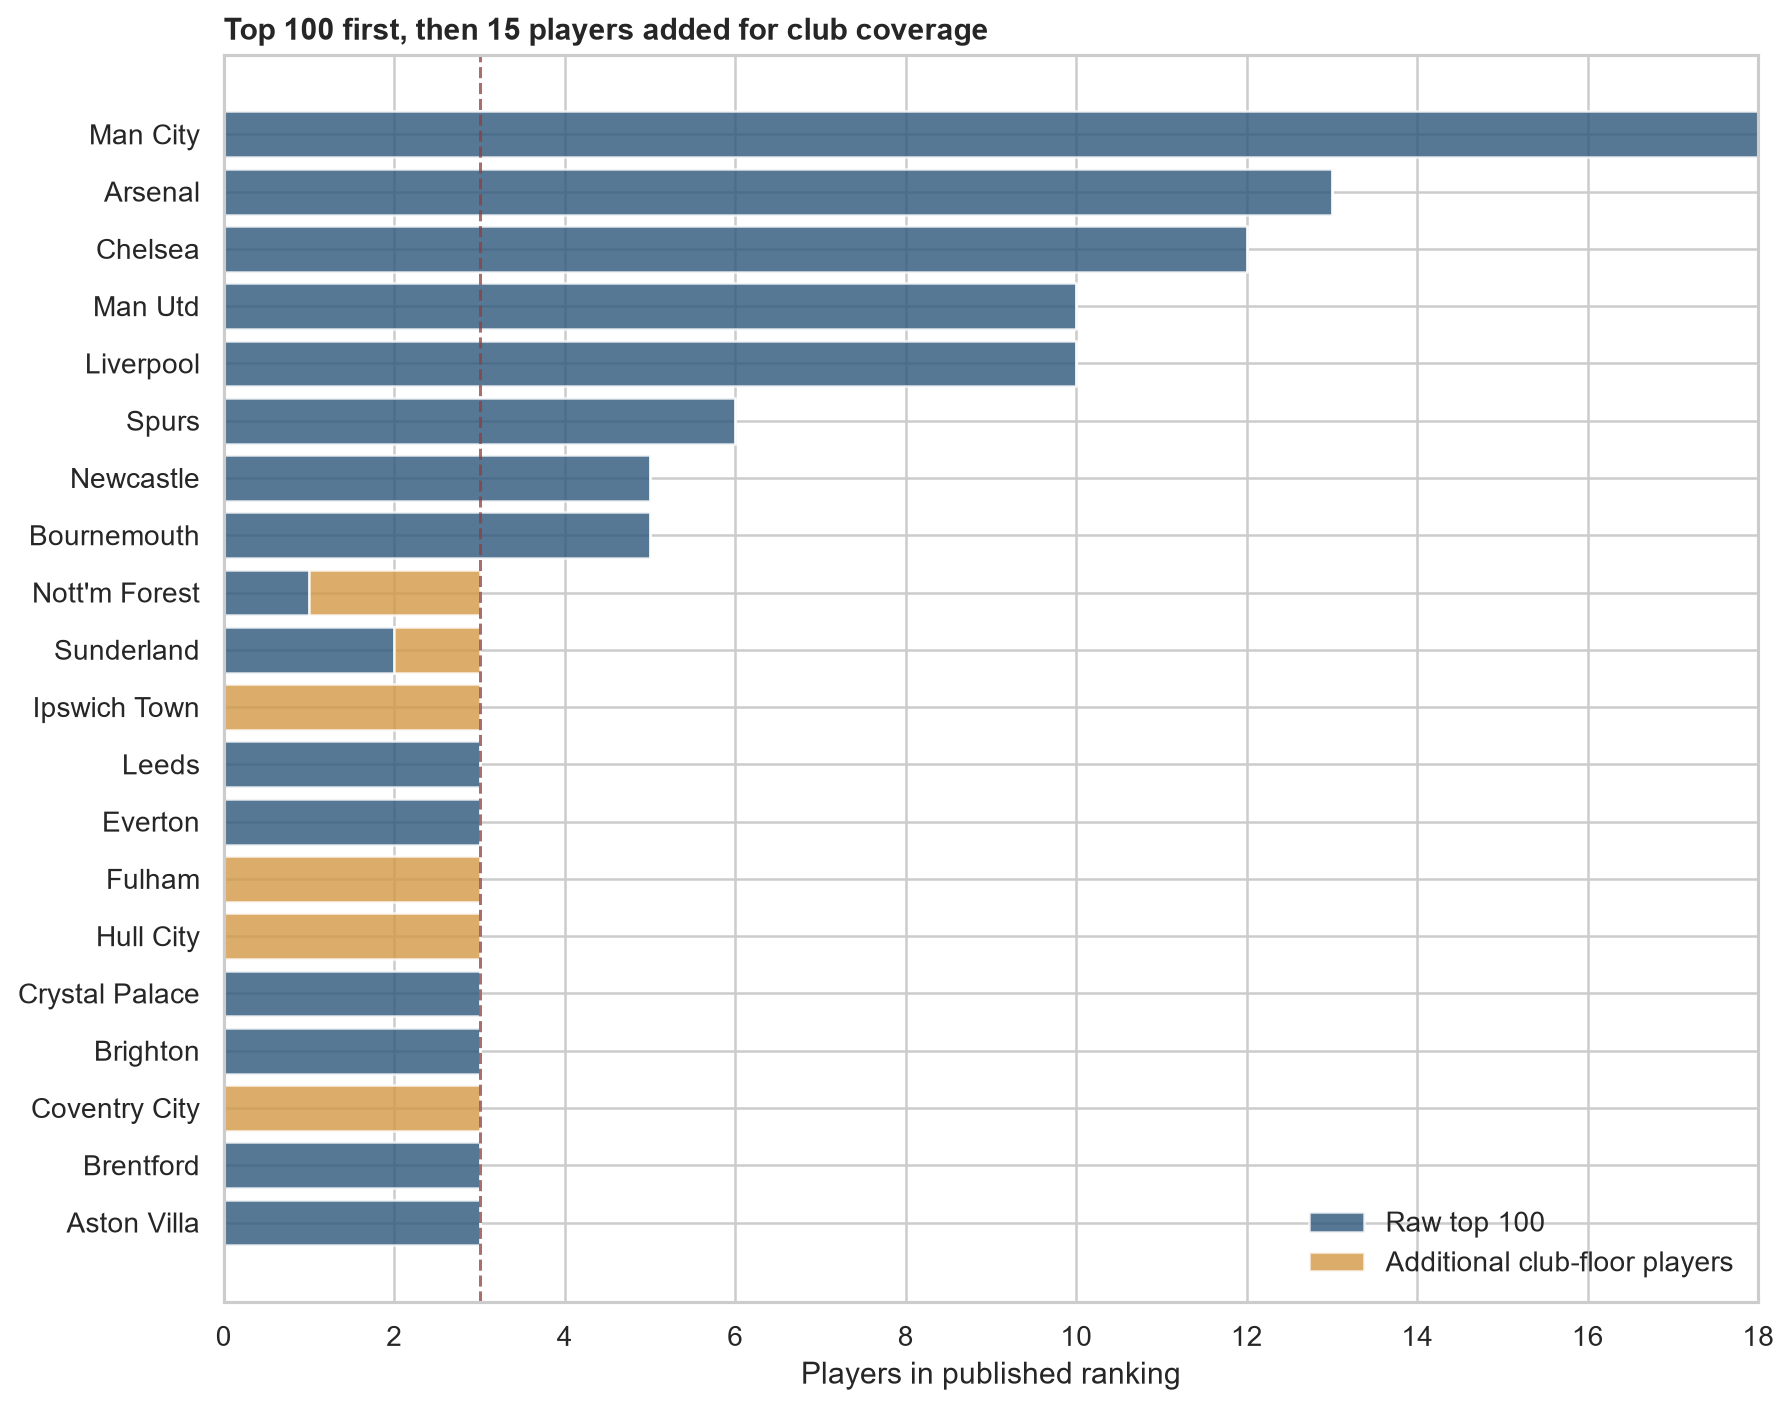

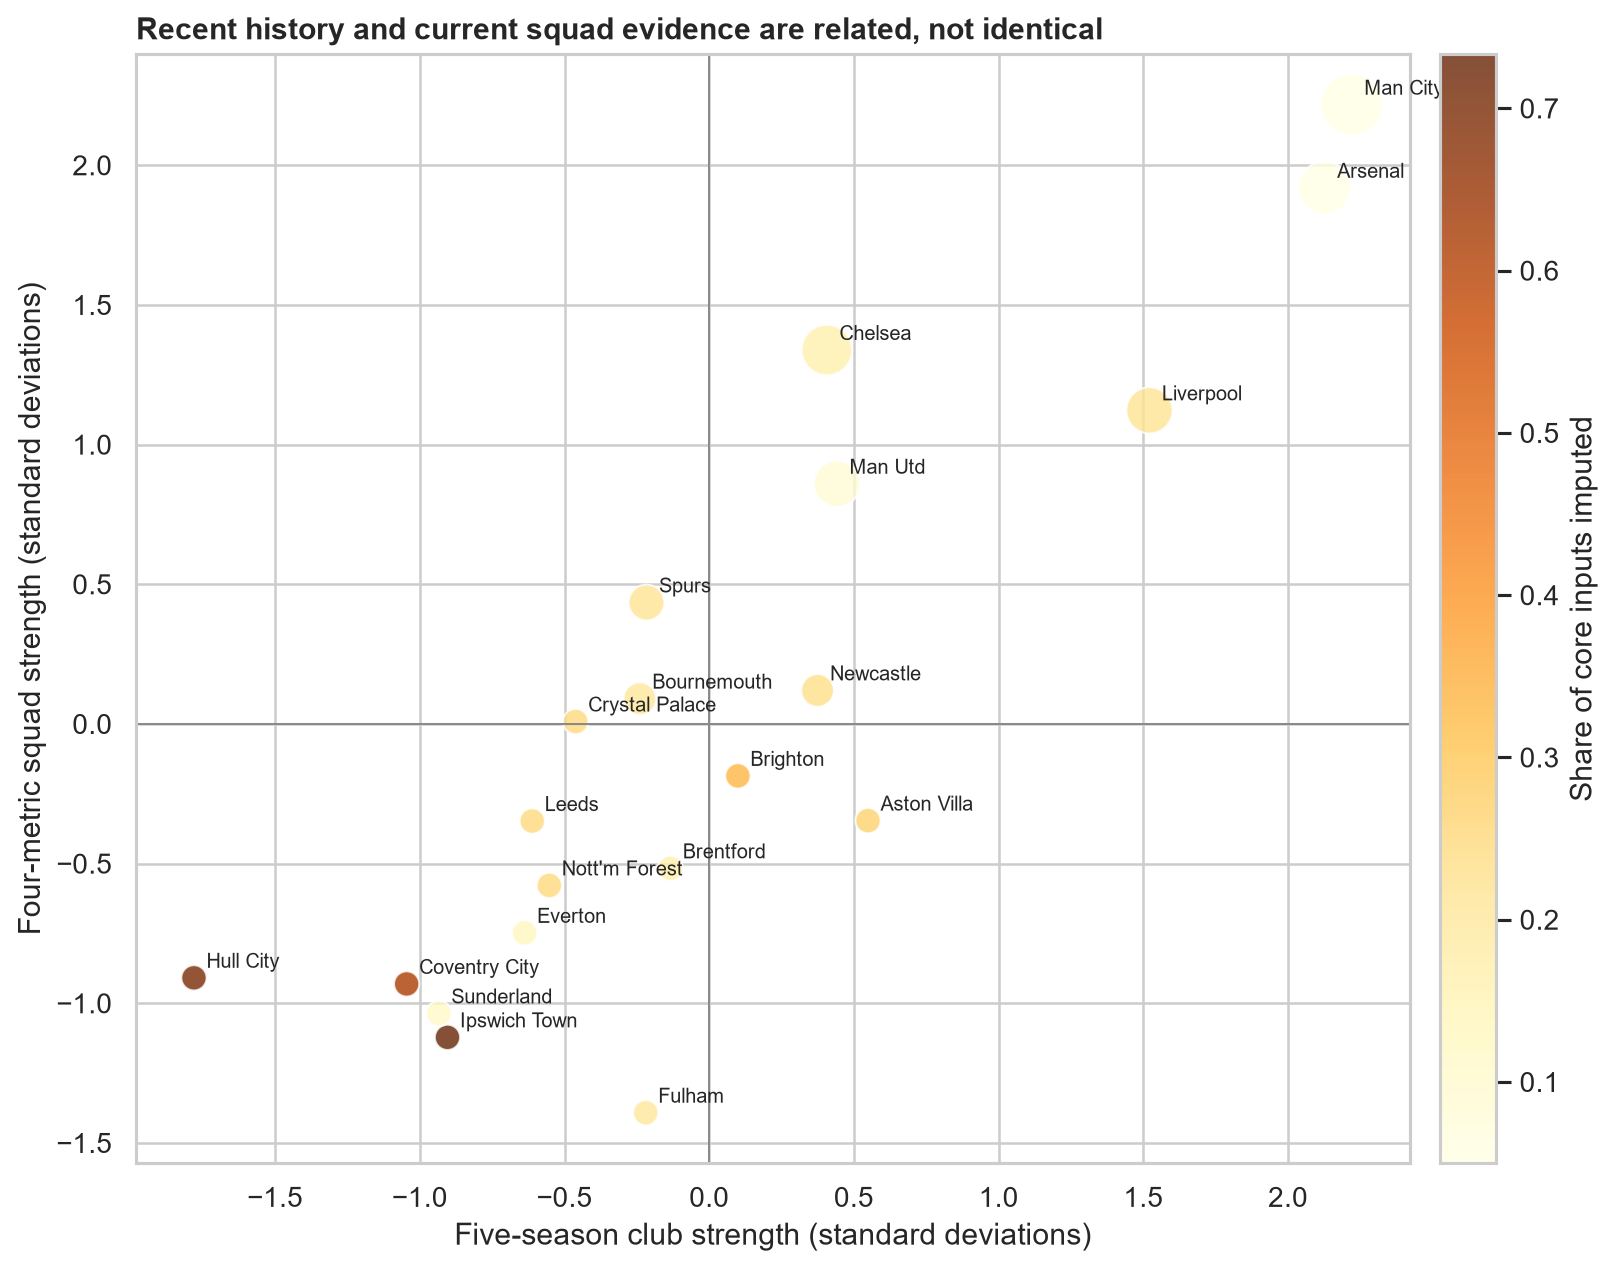

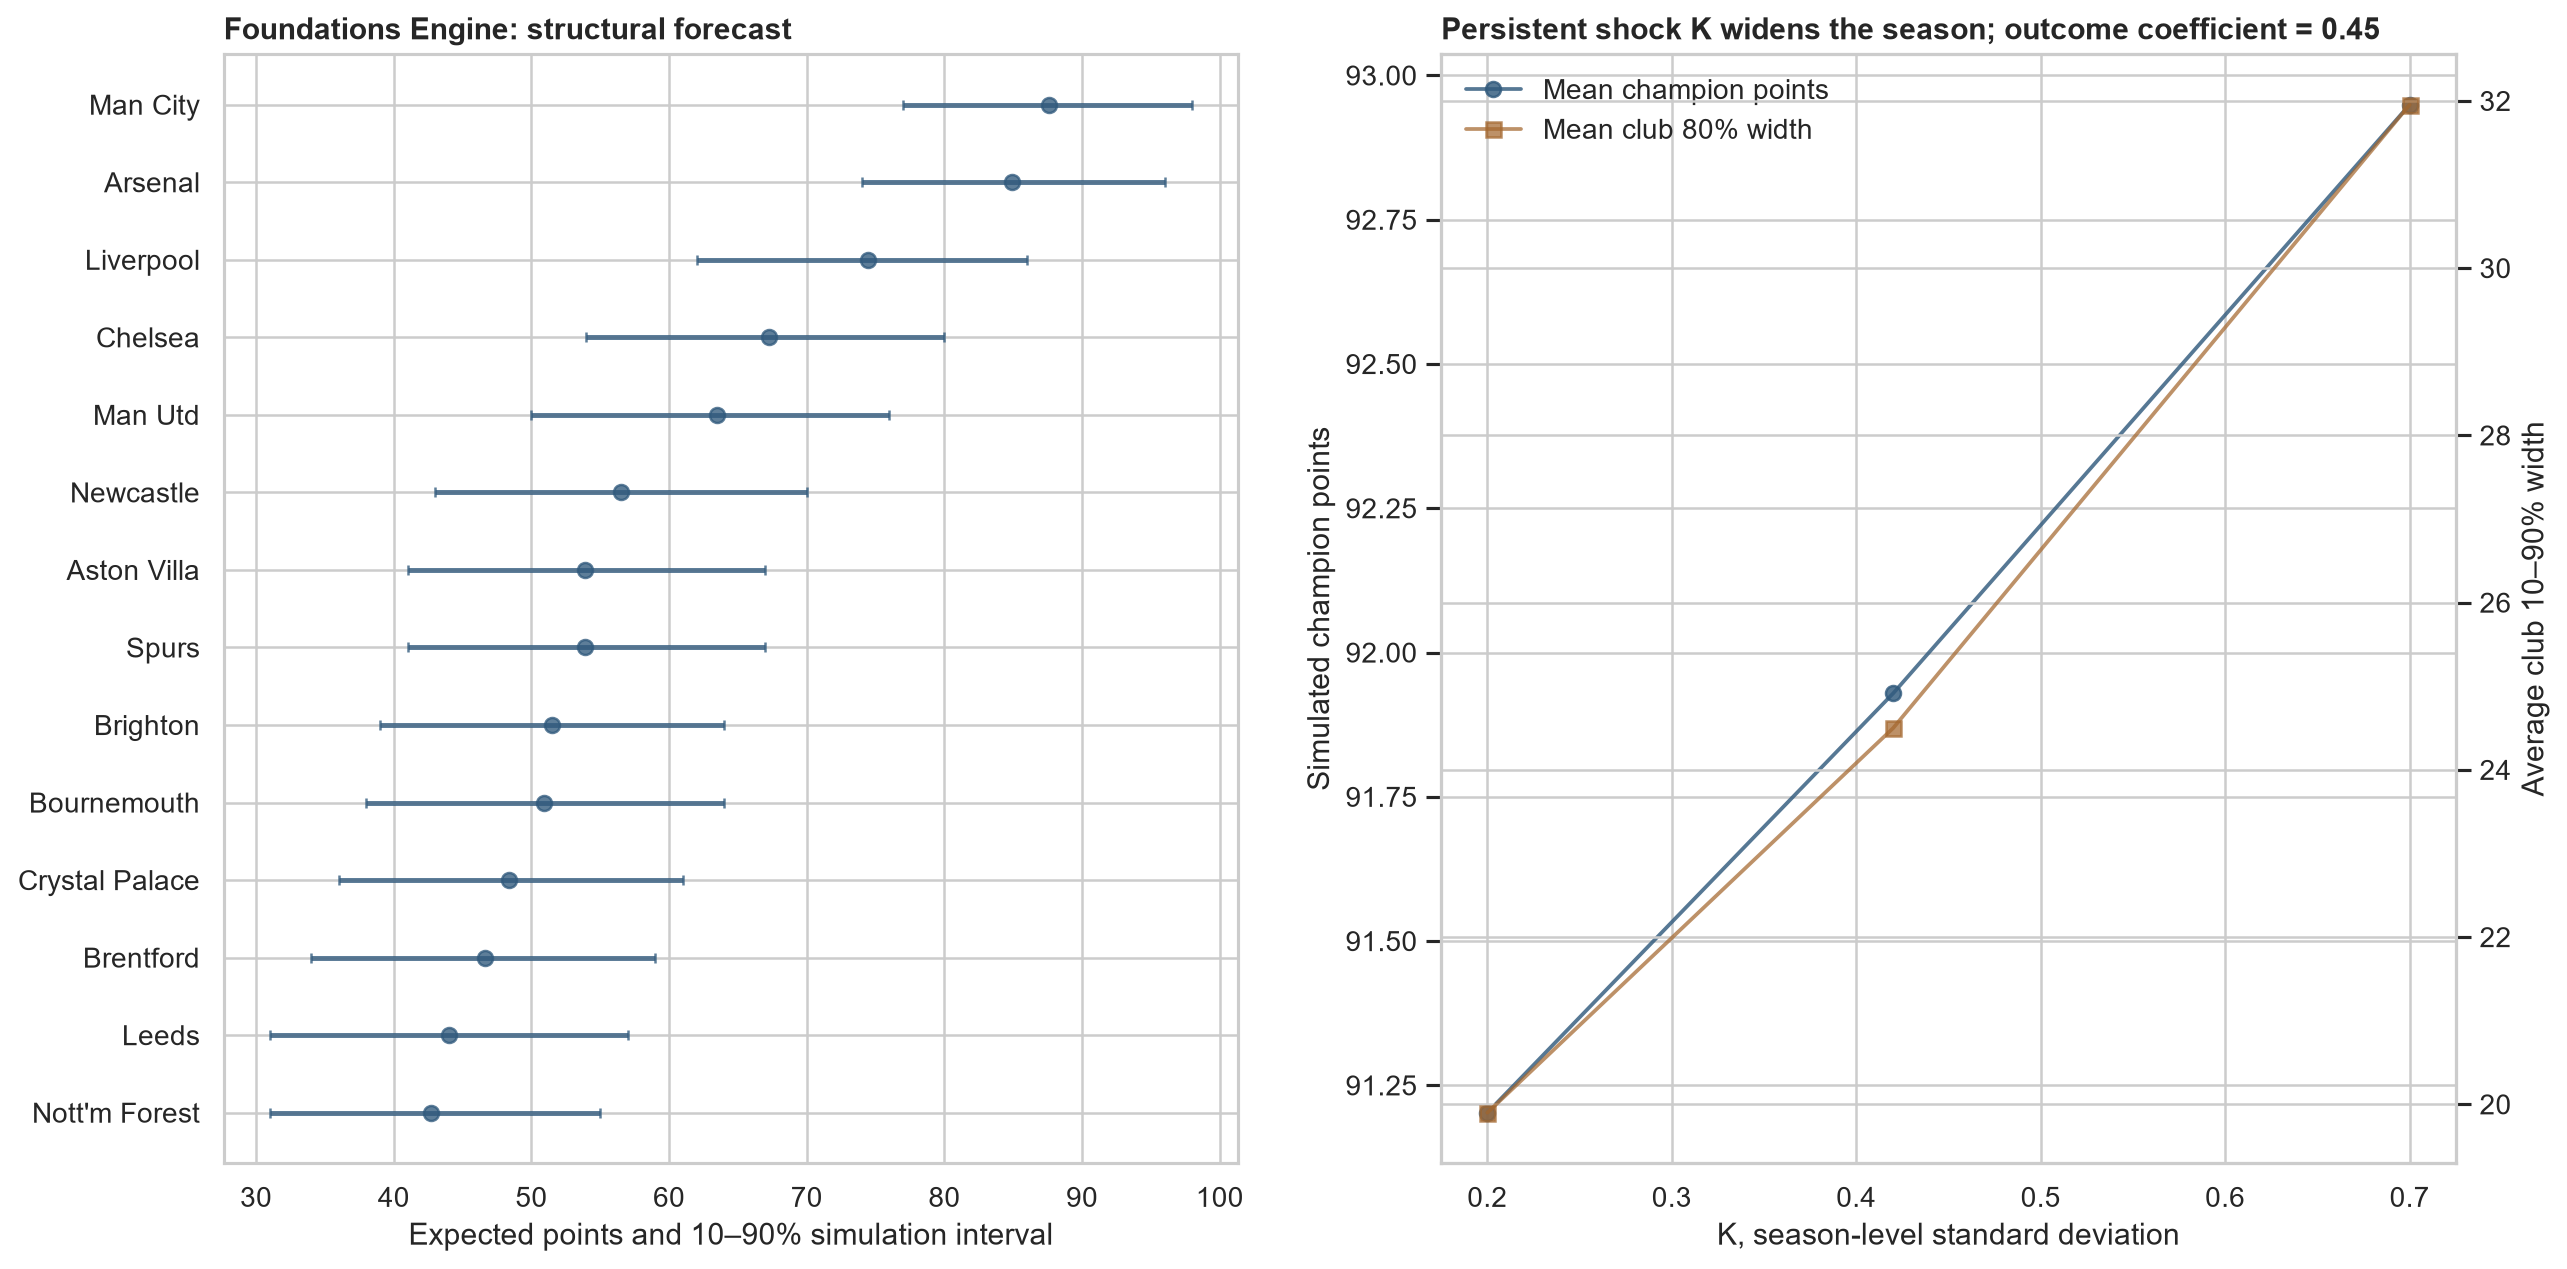

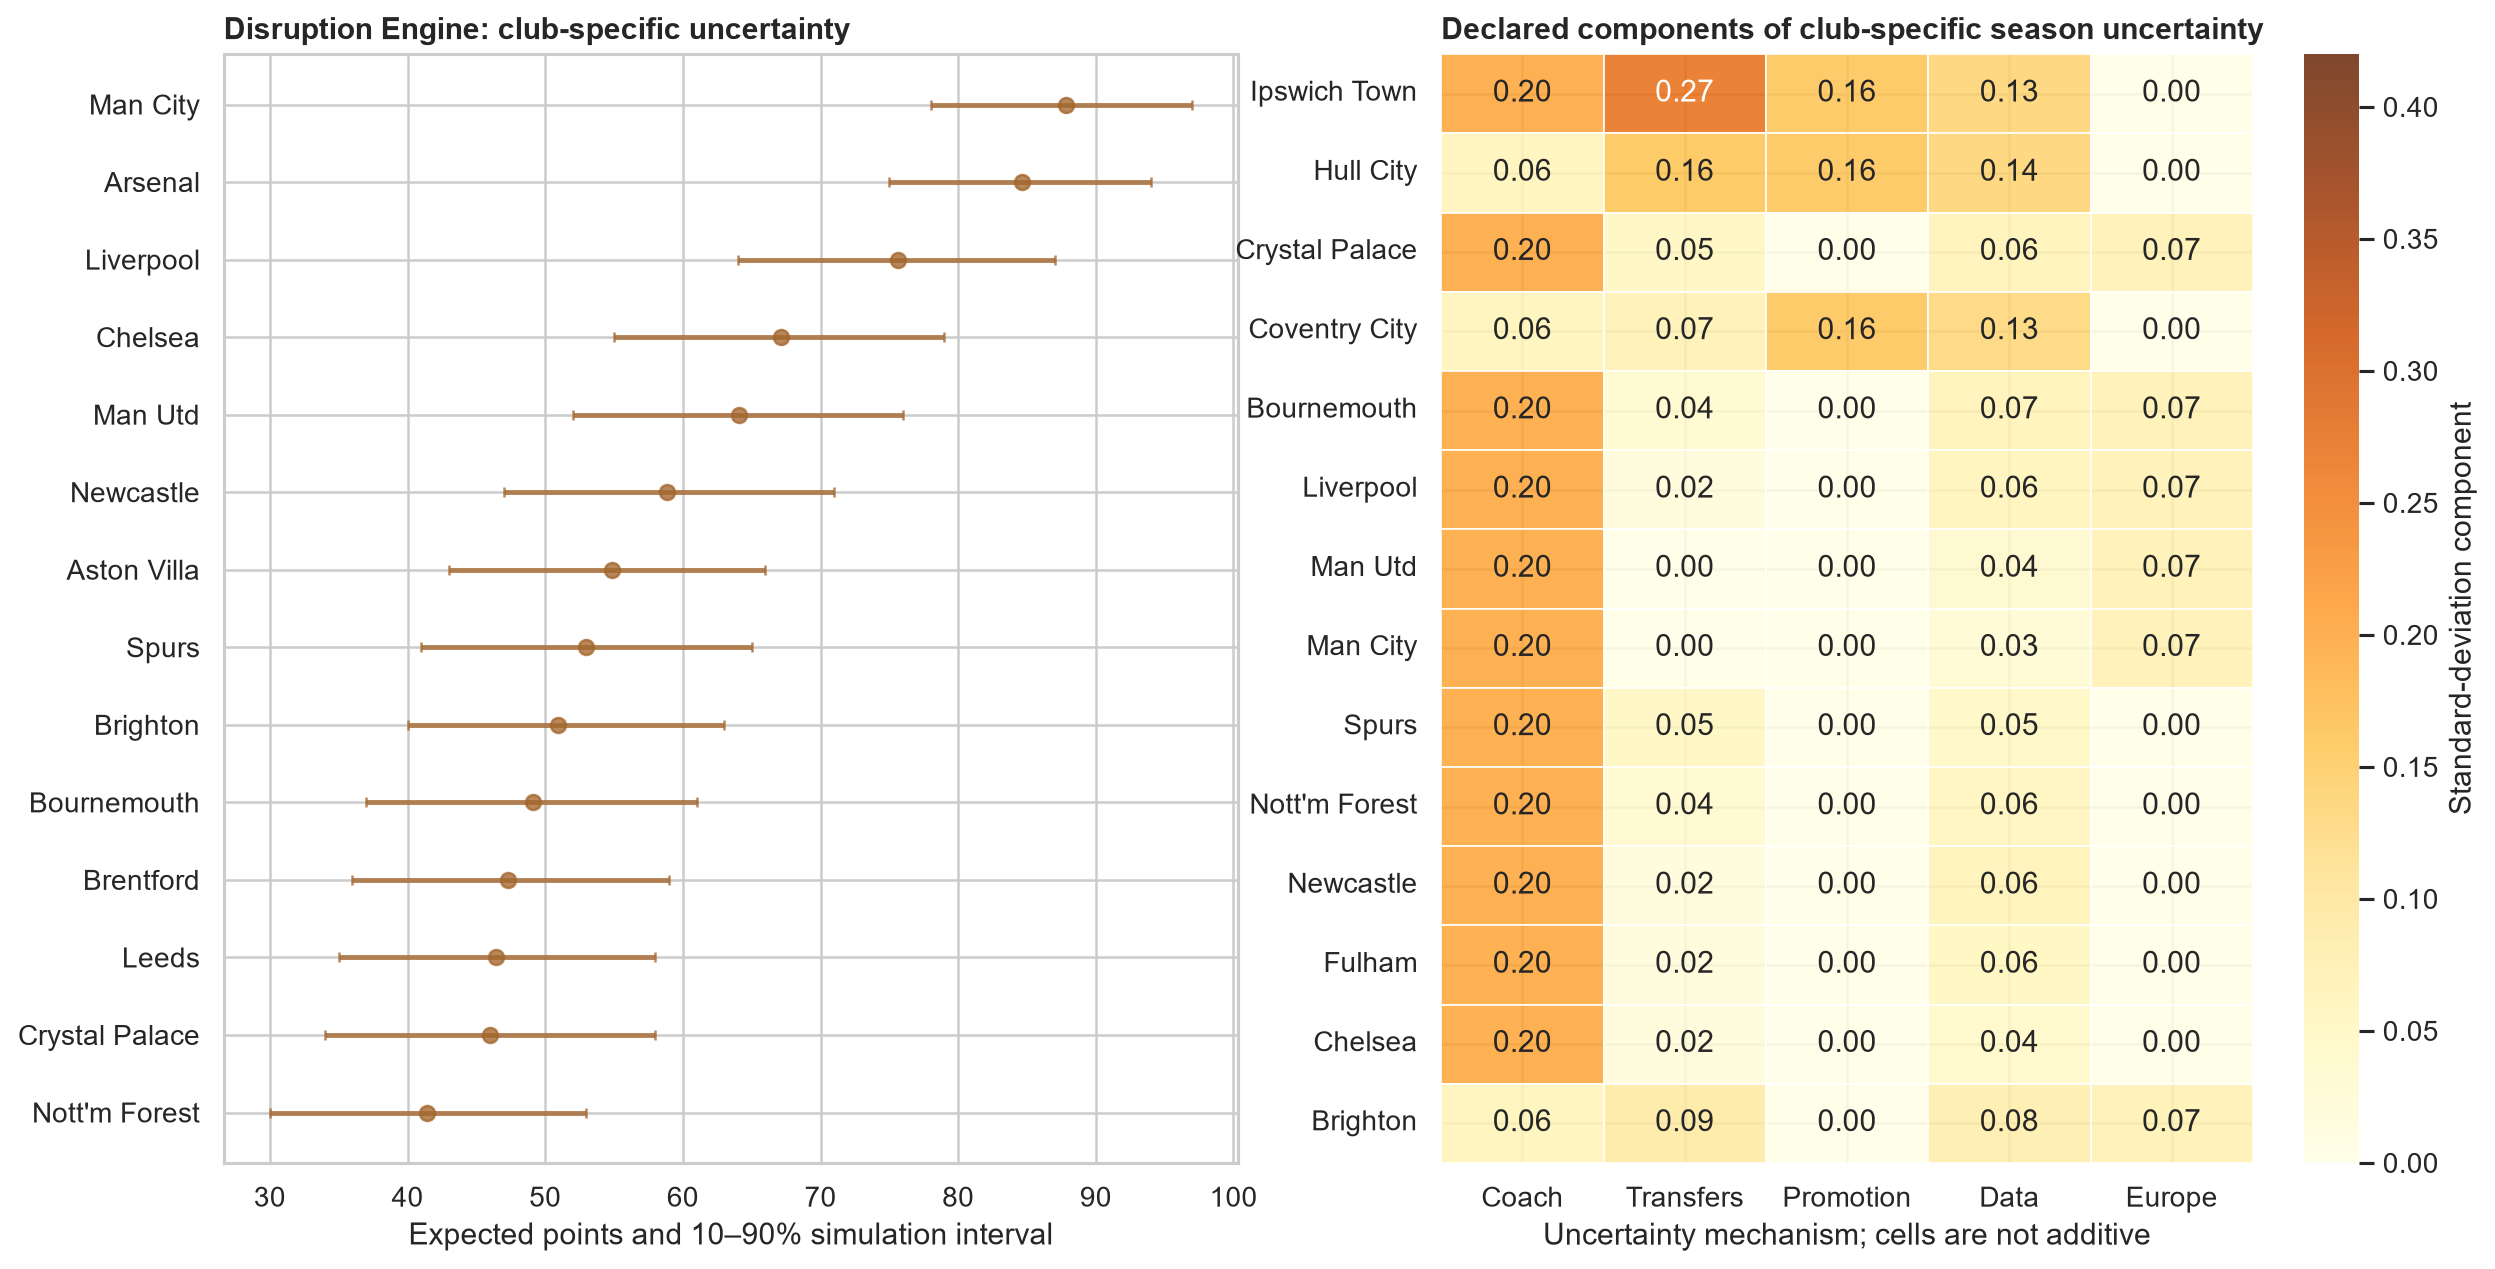

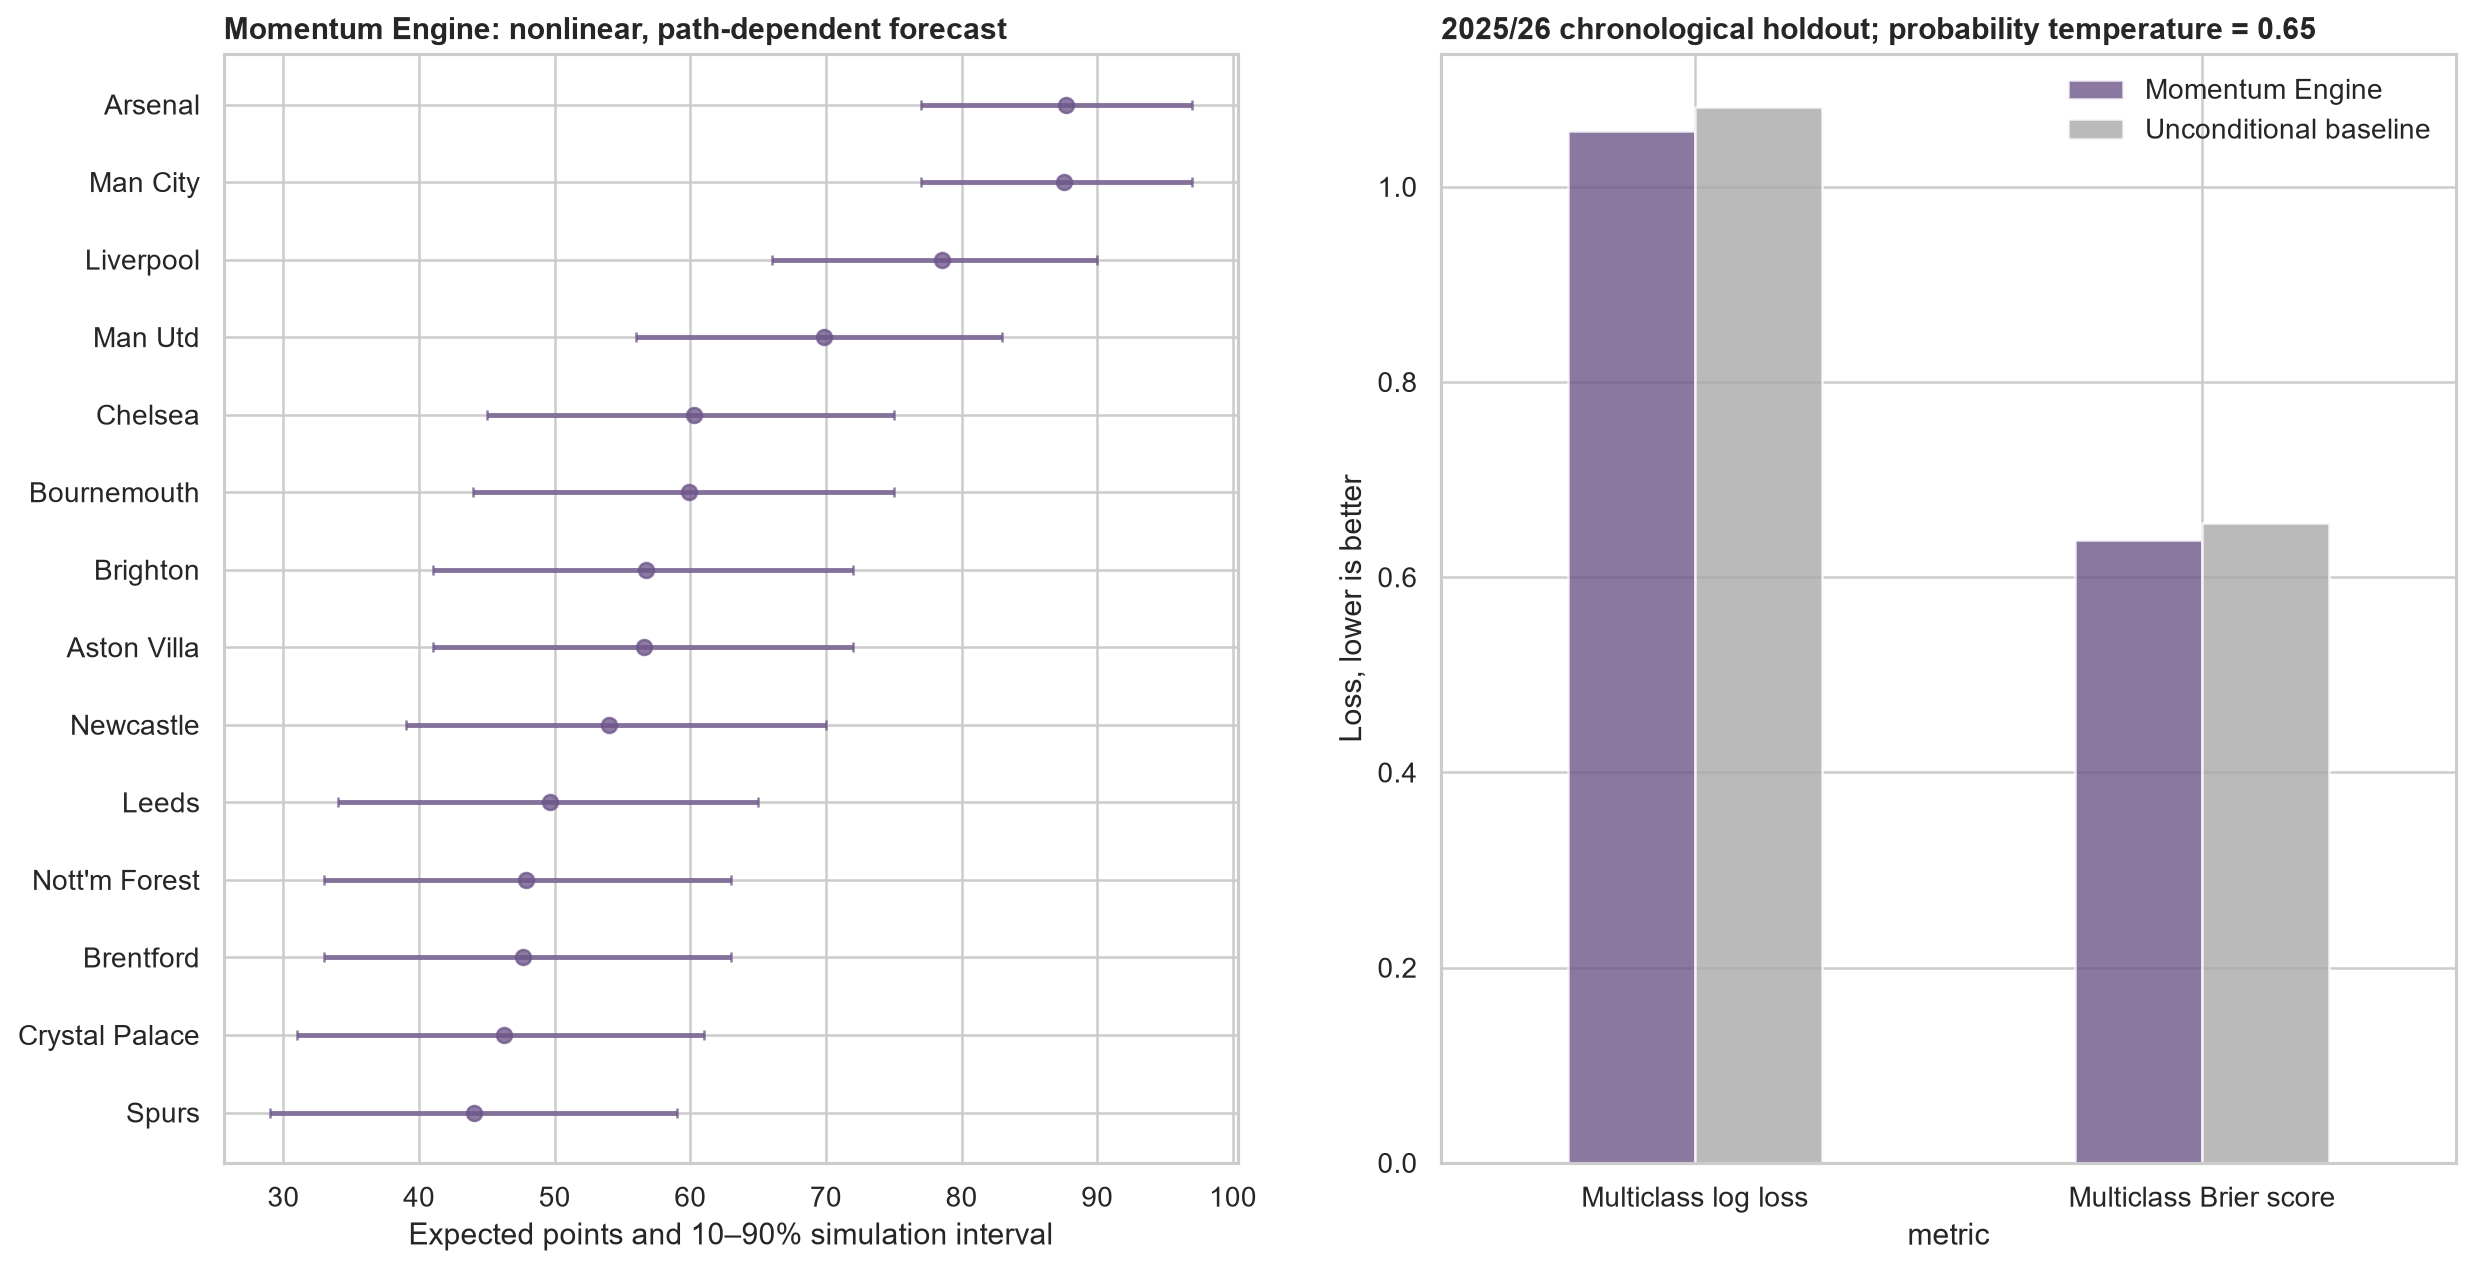

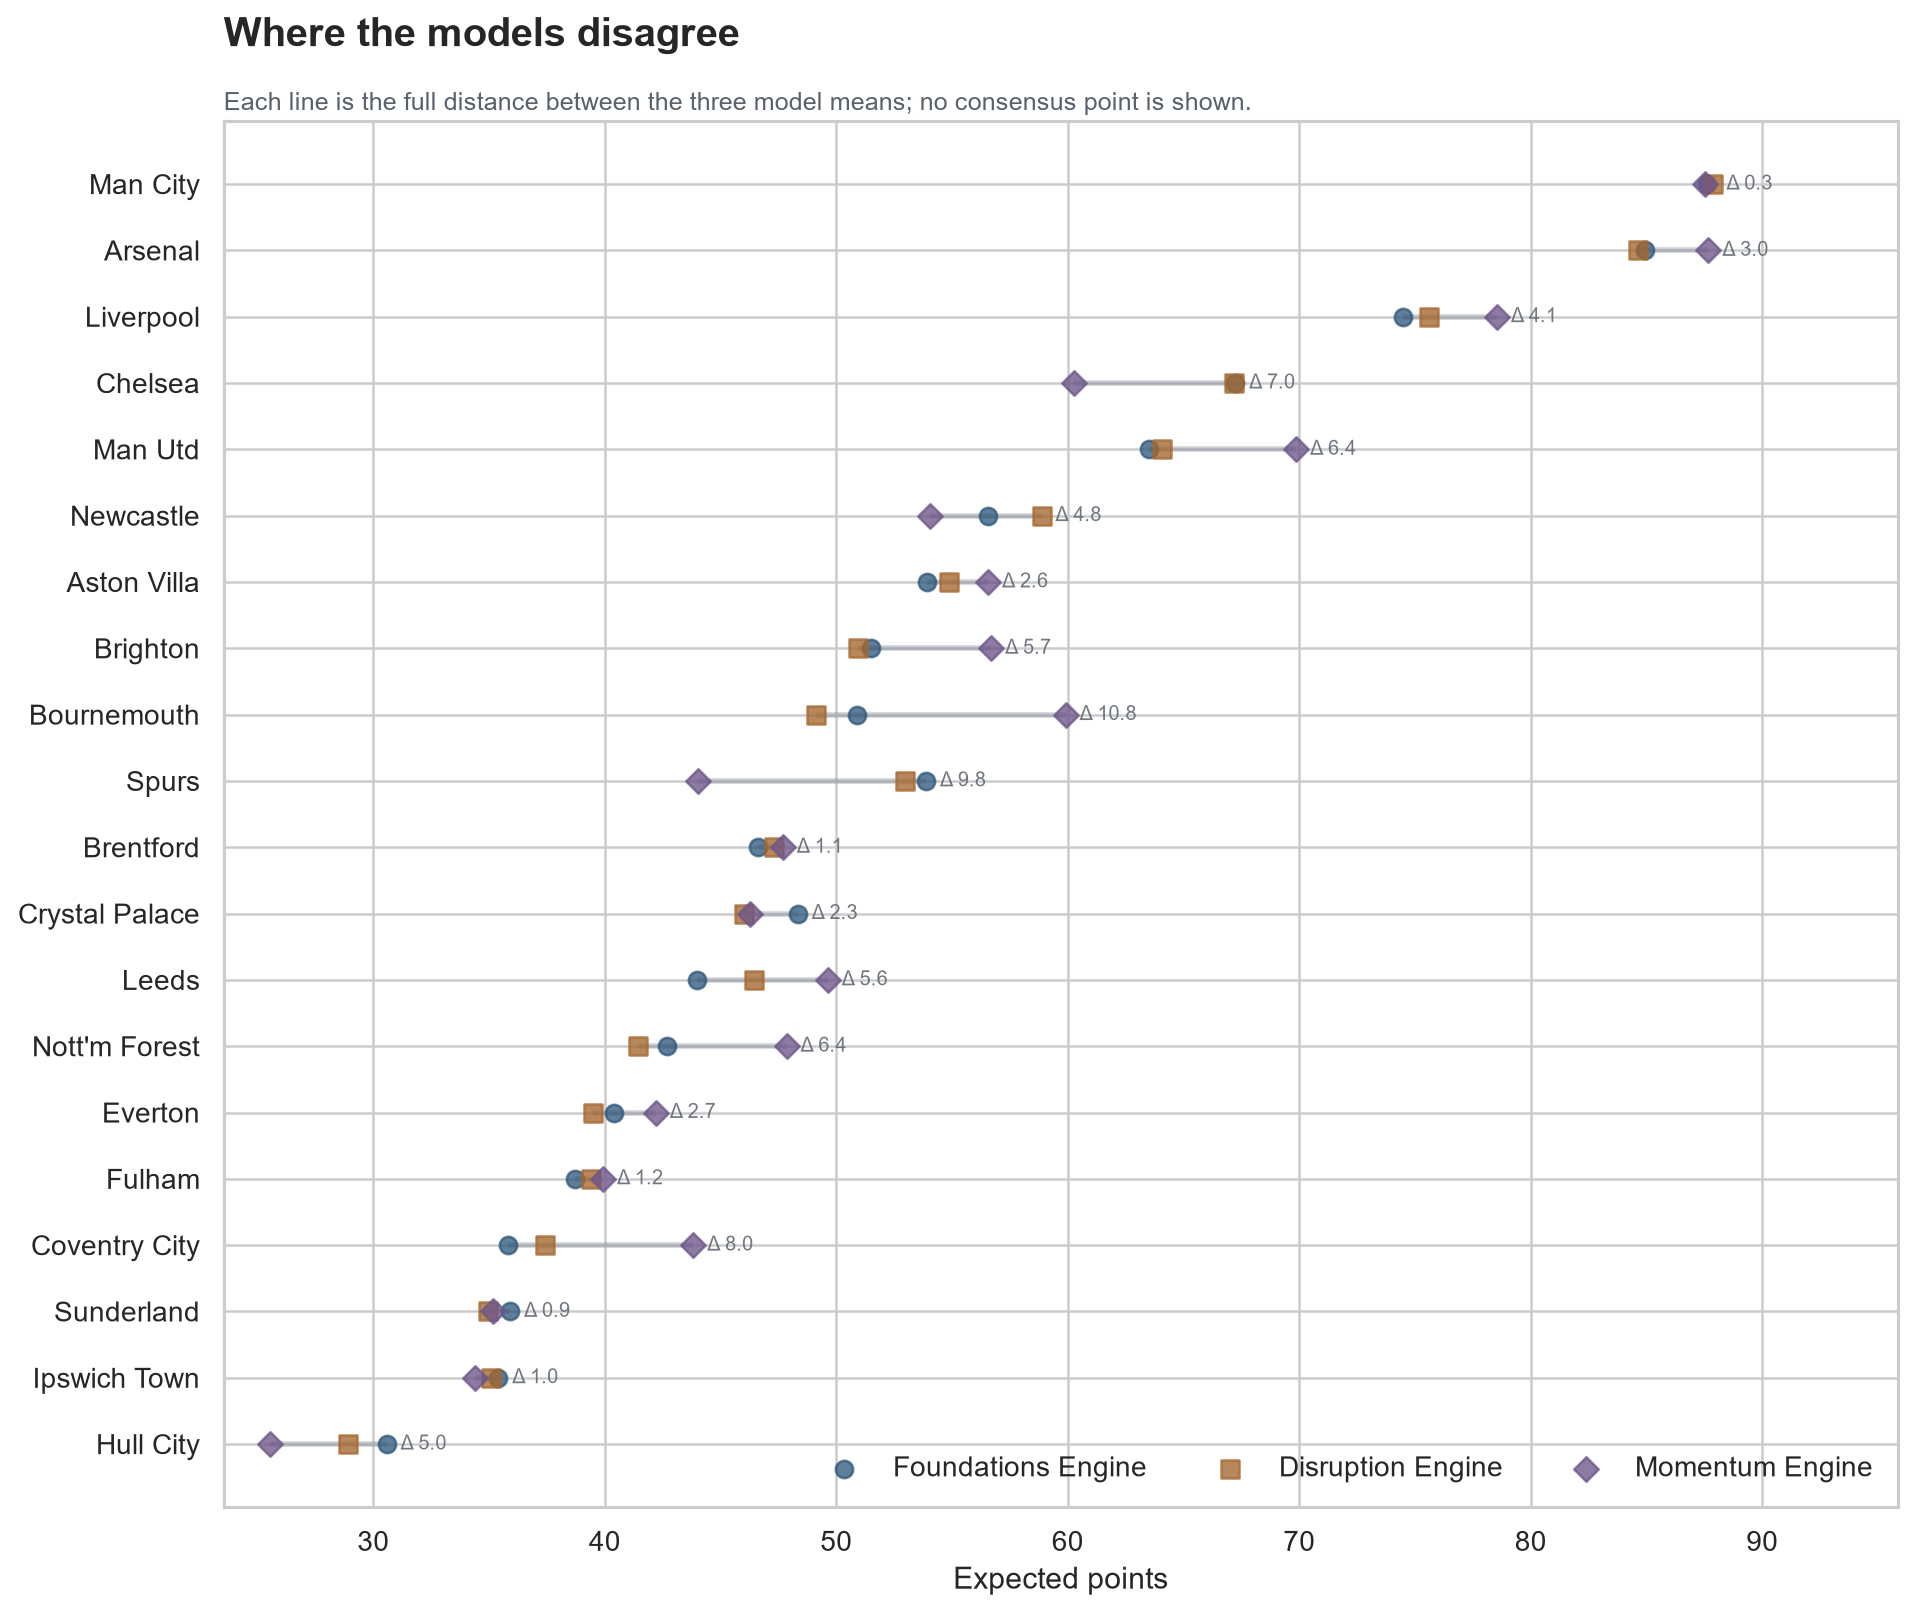

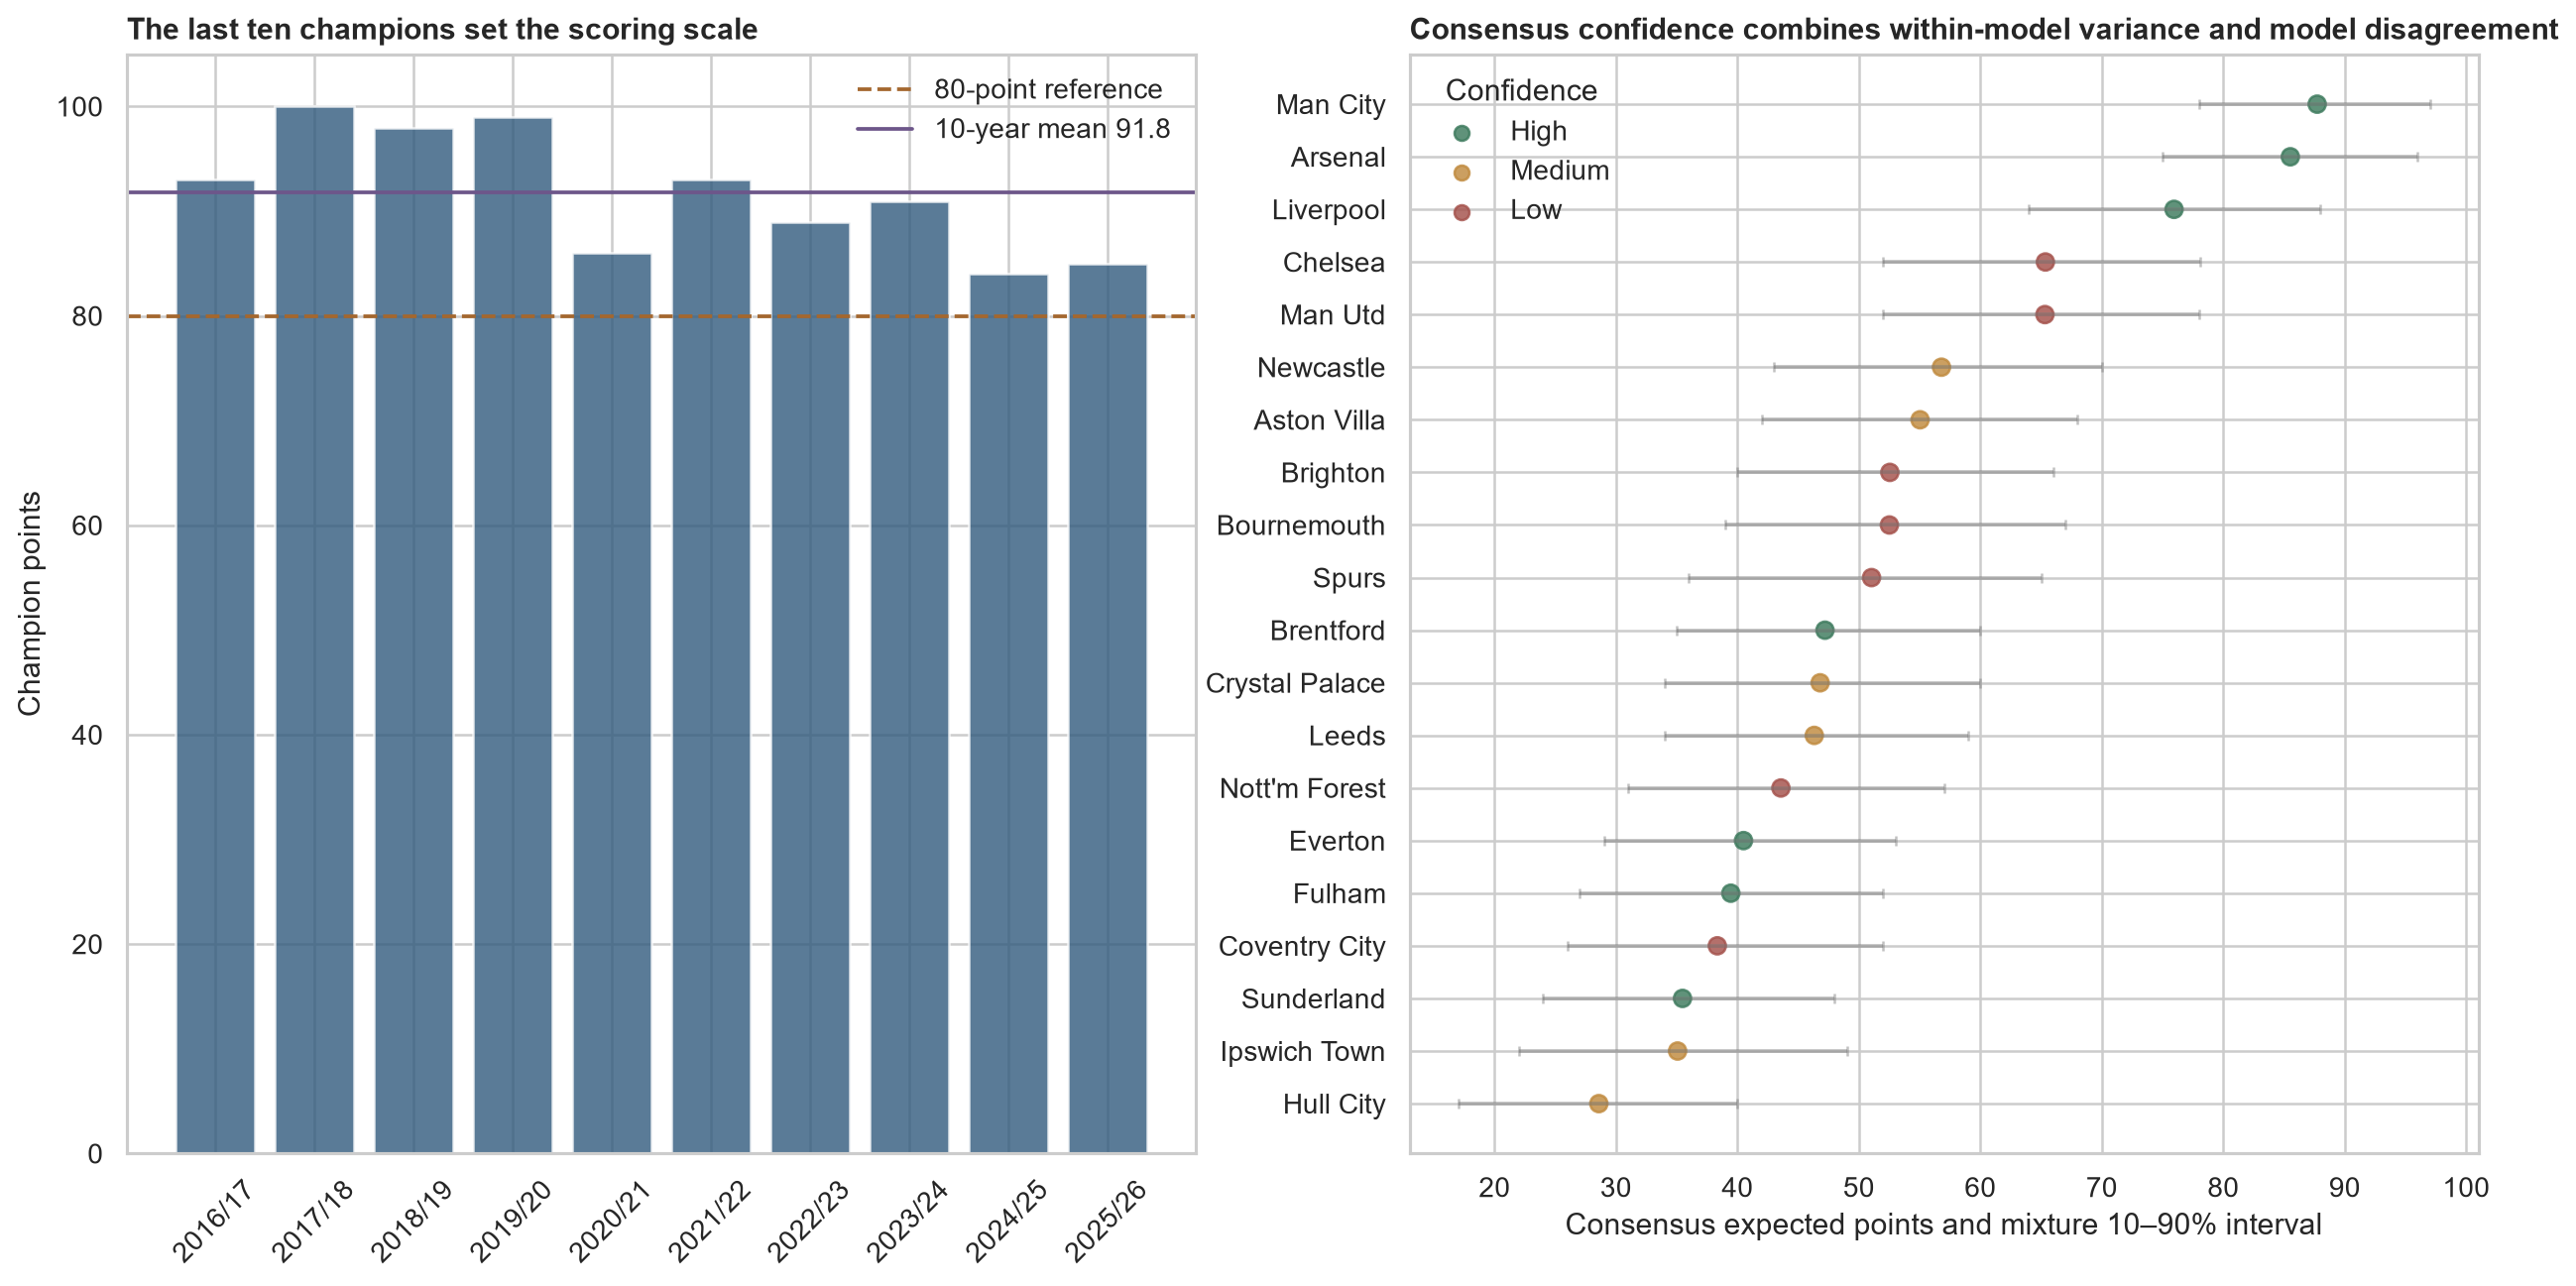

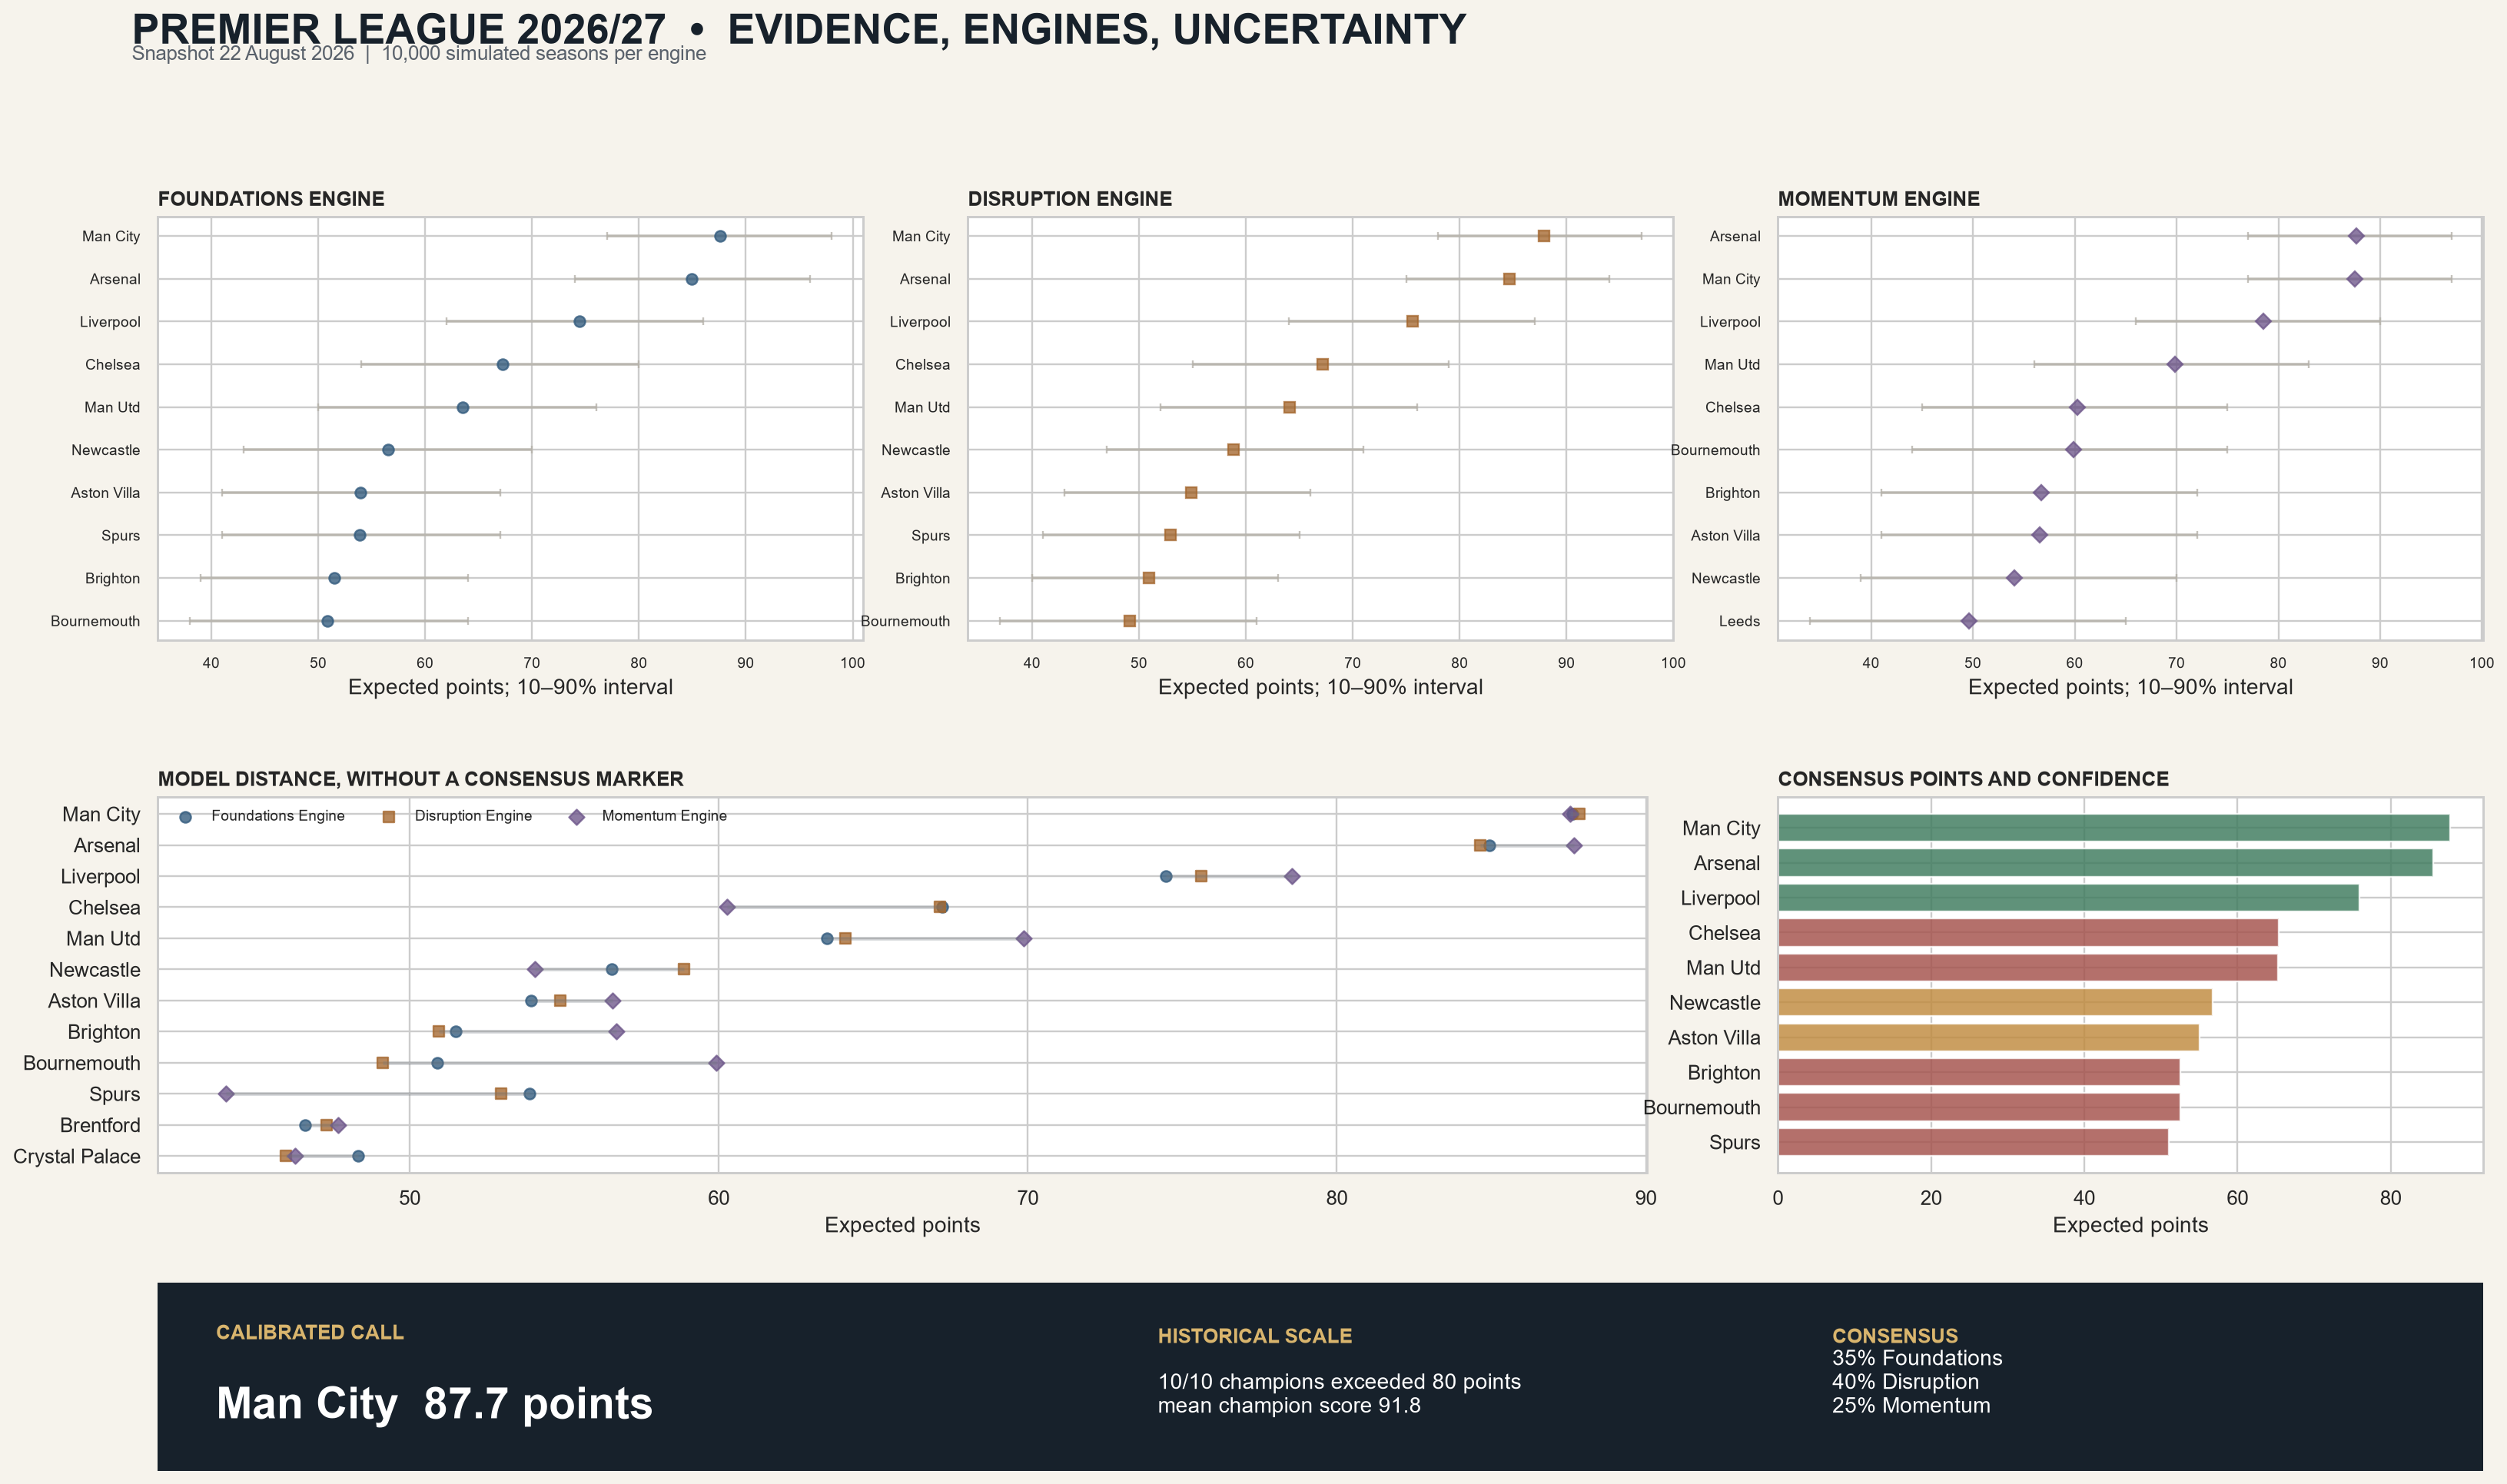

In [3]:
from IPython.display import display, Image
display(pd.read_csv(OUT / 'final_points_table.csv'))
for filename in ['02-club-representation.png', '03-history-vs-squad-strength.png', '04-foundations-engine.png', '05-disruption-engine.png', '06-momentum-engine.png', '07-model-disagreement.png', '08-calibration-confidence.png', '99-synthesis-board.png']:
    display(Image(filename=str(OUT / filename)))